# Definitions

<b>Delta ($\Delta$)</b>

<li>Delta measures how much the option’s premium changes when the underlying asset’s price changes by one dollar.</li>

<li>For a call option, delta ranges between 0 and +1.0.</li>

<li>For a put option, delta ranges between 0 and -1.0.</li>

<li>Example: A delta of 0.4 means the option price increases by \$0.40 for each \$1 increase in the stock price.</li>

<li>Delta also approximates the probability of the option expiring in the money.</li>

<b>Gamma ($\Gamma$)</b>

<li>Gamma measures the rate of change of delta as the underlying price changes.</li>

<li>It shows how delta will shift when the asset price moves.</li>

<li>High gamma means delta changes quickly, often around at-the-money options.</li>

<li>Example: If delta is 0.4 and gamma is 0.05, a \$1 price increase in the stock makes the new delta 0.45.</li>

<b>Theta ($\theta$)</b>

<li>Theta represents the time decay of an option’s value — how much an option’s premium decreases each day, assuming all else is constant.</li>

<li>It’s generally negative for option buyers because options lose time value as expiration approaches.</li>

<li>Sellers benefit from theta because the option they sold depreciates in value over time.</li>

<b>Vega ($v$)</b>

<li>Vega measures sensitivity to volatility (IV) — how much the option price changes for a 1% change in implied volatility.</li>

<li>Higher volatility increases both call and put premiums.</li>

<li>Long options (buyers) benefit from rising volatility; short options (sellers) are hurt by it.</li>

<b>Rho ($\rho$)</b>

<li>Rho measures how much an option’s price changes with a 1% change in interest rates.</li>

<li>Call options have positive rho — higher rates increase call values.</li>

<li>Put options have negative rho — higher rates decrease put values.</li>

<li>It becomes more relevant for long-term options than near-expiry ones</li>

# Imports

In [1]:
import sys

repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
sys.path.append(repo_path)
from src.utils.alpaca_utils import *

with open(os.path.join(cache_path, 'headers.pkl'), 'rb') as file: 
    headers, paper_header = pkl.load(file)

# Options Data

In [6]:
symbol = 'QCOM'

########################################
####### Get options information ########
########################################
option_details, strike_group, current_price = get_options_information(symbol = symbol,
                                                                       start_day_offset = 30,
                                                                       end_day_offset = 120,
                                                                       option_type = 'call',
                                                                       percentage_to_search = 0.1,
                                                                       headers = headers)
display(option_details)

########################################
####### Filter Possible Trades #########
########################################
o = filter_option_trades_by_ff(strike_group = strike_group,
                           current_price = current_price,
                           min_time_distance = 25,
                           max_time_distance = 95,
                           min_ff_perc = 20, 
                           max_ff_perc = 50)


Symbol | QCOM
Current Price: 173.46 (Time : 2025-11-06T15:35:00Z)


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price
0,QCOM251212C00175000,2025-12-12,175,13.52,call,0.4988,0.0218,0.0785,-0.11,0.2171,0.3363,7.12,6.52
1,QCOM251219C00175000,2025-12-19,175,12.9,call,0.5033,0.0209,0.0943,-0.0972,0.2373,0.321,7.31,7.08
2,QCOM260116C00175000,2026-01-16,175,15.38,call,0.5222,0.0162,0.1573,-0.0778,0.3044,0.3225,9.72,9.57
3,QCOM260220C00175000,2026-02-20,175,17.4,call,0.5399,0.0124,0.2342,-0.0686,0.3707,0.3439,13.04,12.77
4,QCOM251212C00180000,2025-12-12,180,11.3,call,0.391,0.0214,0.0622,-0.1026,0.209,0.3301,4.91,4.44
5,QCOM251219C00180000,2025-12-19,180,9.9,call,0.4047,0.02,0.0764,-0.0945,0.2305,0.3265,5.47,5.1
6,QCOM260116C00180000,2026-01-16,180,12.25,call,0.4439,0.016,0.1349,-0.0763,0.3019,0.324,7.63,7.52
7,QCOM260220C00180000,2026-02-20,180,16.42,call,0.4802,0.0123,0.2101,-0.0686,0.3721,0.3471,11.15,10.59
8,QCOM251212C00185000,2025-12-12,185,7.67,call,0.2966,0.0191,0.0475,-0.0924,0.1882,0.3336,3.48,2.97
9,QCOM251219C00185000,2025-12-19,185,7.9,call,0.3163,0.0181,0.0601,-0.0869,0.2117,0.3308,4,3.59


############################################
####### Strike Price (Current Price) #######
############## 175 (173.46) ################
############################################

############################################
####### Strike Price (Current Price) #######
############## 180 (173.46) ################
############################################

############################################
####### Strike Price (Current Price) #######
############## 185 (173.46) ################
############################################

############################################
####### Strike Price (Current Price) #######
############## 190 (173.46) ################
############################################

Forward Ratio: 28.309% | DTE Front (Sell): 35 | DTE Back (Buy): 70


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,QCOM251212C00190000,2025-12-12,190,5.75,call,0.2446,0.0154,0.0391,-0.0931,0.1709,0.3739,3.45,2.12,28.309401,-2.73
1,QCOM260116C00190000,2026-01-16,190,8.28,call,0.3095,0.0138,0.0952,-0.0688,0.2694,0.3352,4.85,4.58,28.309401,-2.73


## Execute Trade

In [113]:
# Execute Multi Leg Strategy 
sell_short = 'QCOM251212C00180000'
buy_long = 'QCOM260116C00180000'

paper_trade = False

if not paper_trade:
    url = "https://api.alpaca.markets/v2/orders"
else:
    url = "https://paper-api.alpaca.markets/v2/orders"
payload = {
    "type": "market",
    "time_in_force": "day",
    "legs": [
        {
            "side": "sell",
            "position_intent": "sell_to_open",
            "symbol": sell_short,
            "ratio_qty": "1"
        },
        {
            "position_intent": "buy_to_open",
            "symbol": buy_long,
            "ratio_qty": "1"
        }
    ],
    "order_class": "mleg",
    "qty": "1"
}


confirm = input('Confirm Trade? (y/n) \n')
if not paper_trade: 
    confirm_ = input('NON-PAPER TRADE: Confirm? (y/n) \n')

if confirm == 'y':
    if not paper_trade and confirm_ == 'y': 
        response = requests.post(url, json=payload, headers=headers)
    else:
        response = requests.post(url, json=payload, headers=paper_header)
        
    if response.status_code != 200:
        print(json.loads(response.text))
    else: 
        print ("Order Successfully Completed")
else: 
    print ("Order Aborted")

Confirm Trade? (y/n) 
y
NON-PAPER TRADE: Confirm? (y/n) 
y
Order Successfully Completed


# Historical Stock Data

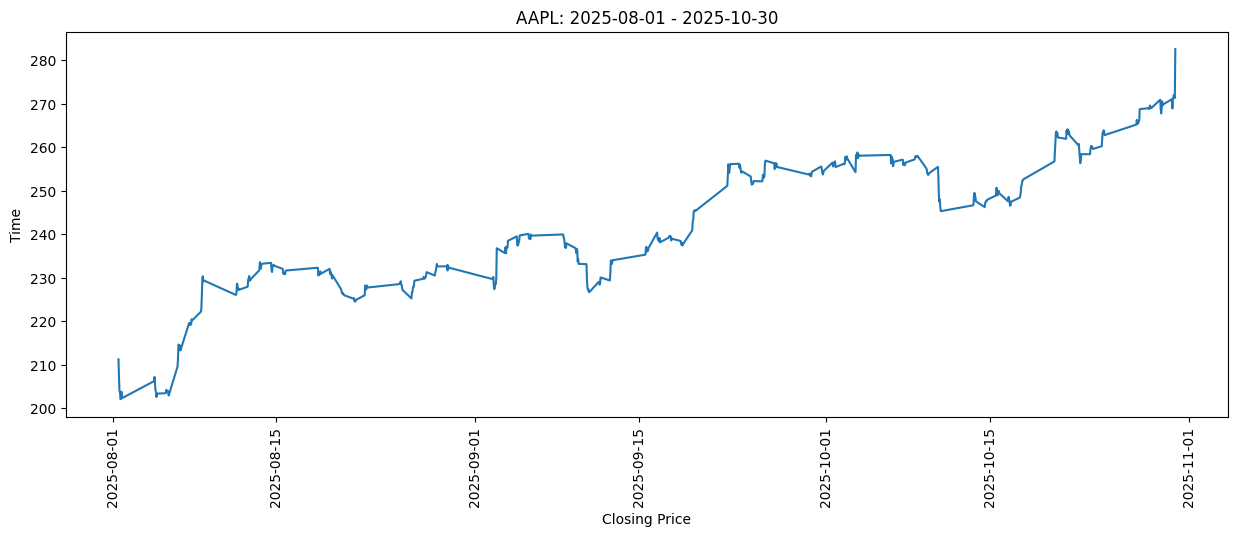

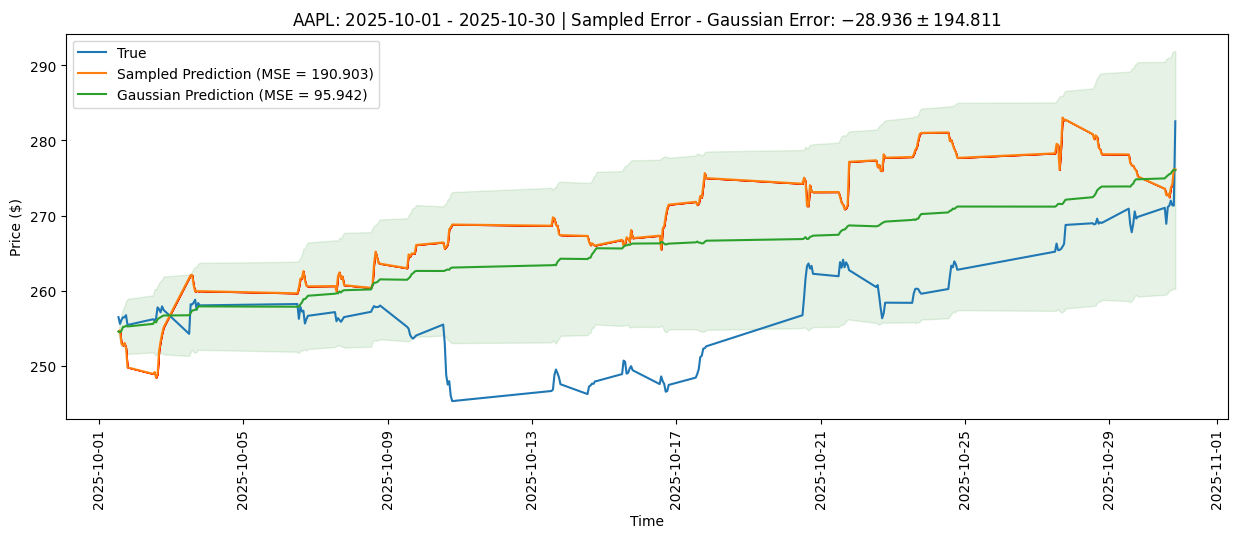

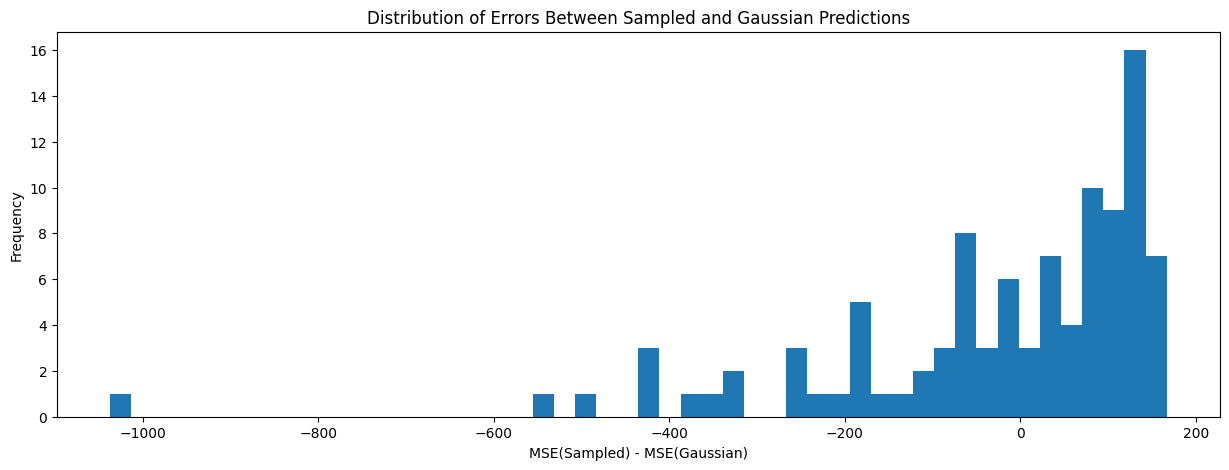

In [18]:
get_prediction_error(symbol = 'AAPL',
                     timeframe = '1H',
                     train_start_date = '2025-08-01',
                     train_end_date = '2025-10-01',
                     test_start_date = '2025-10-01',
                     test_end_date = '2025-10-30', 
                     headers = headers)

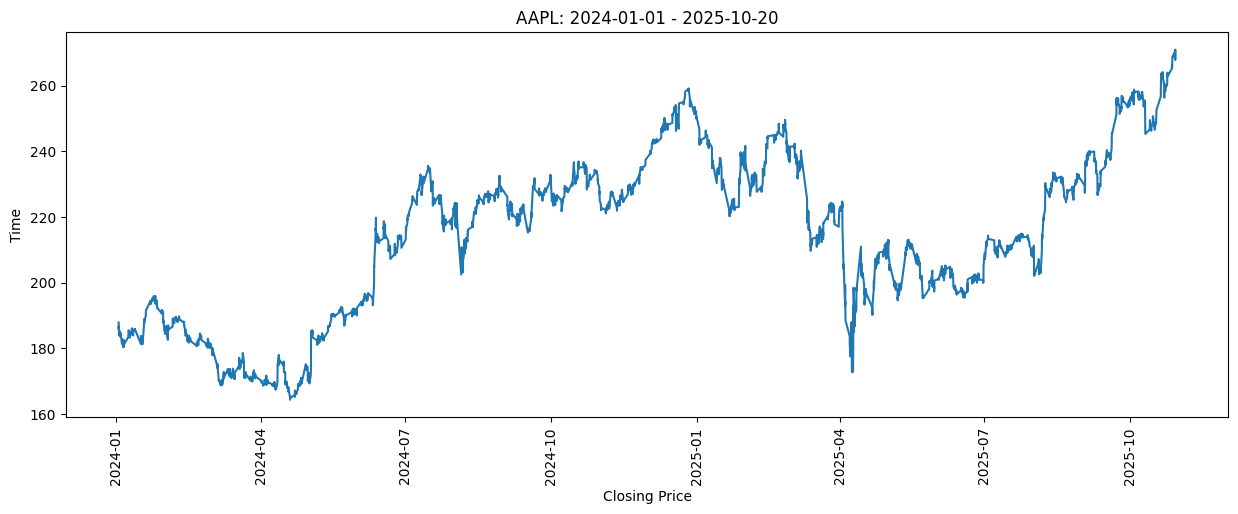

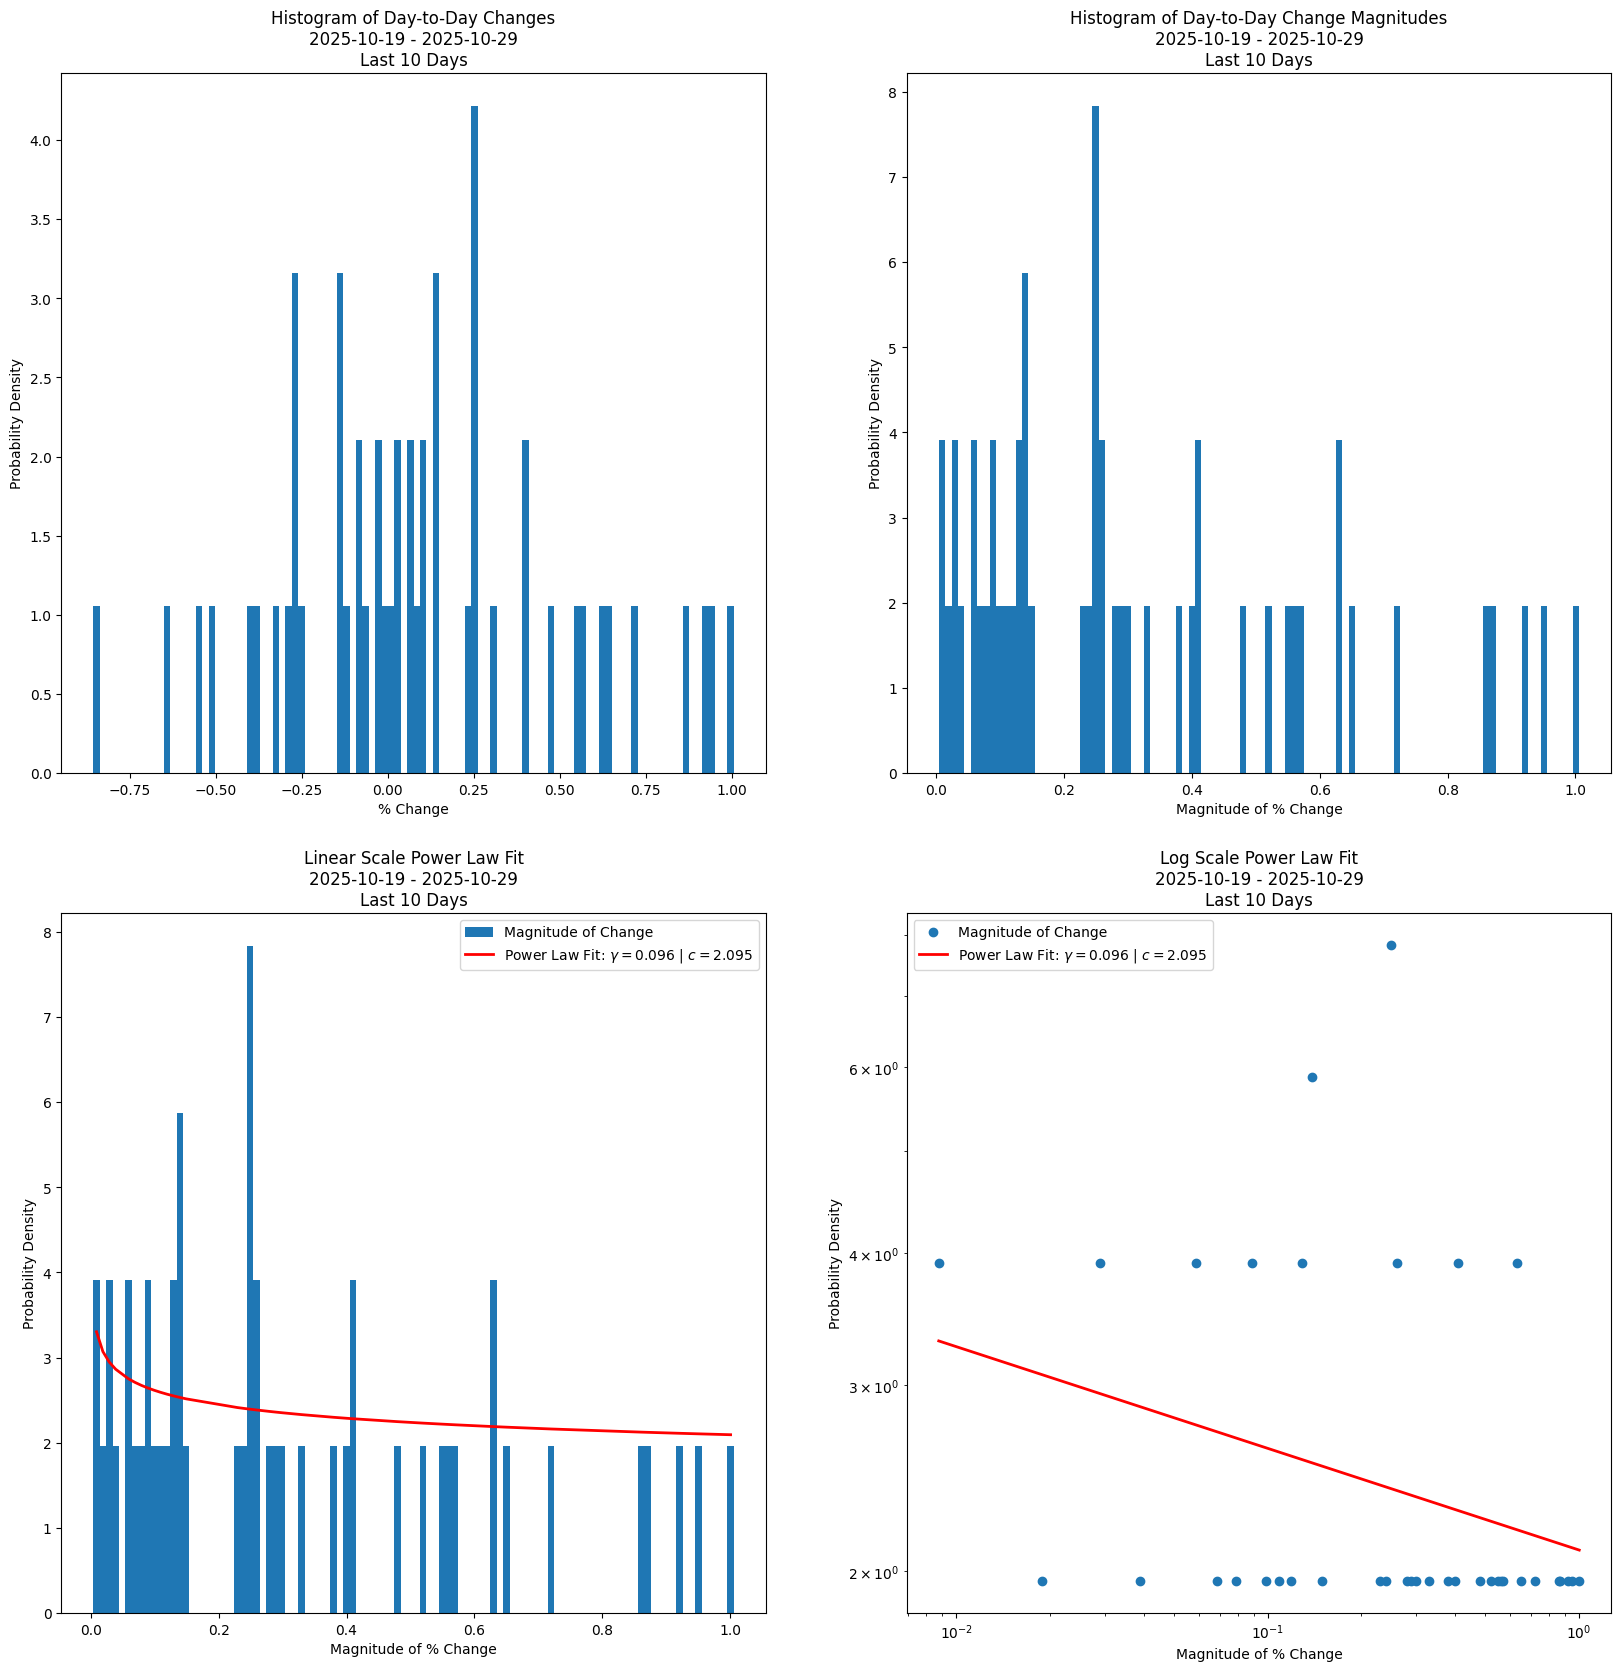

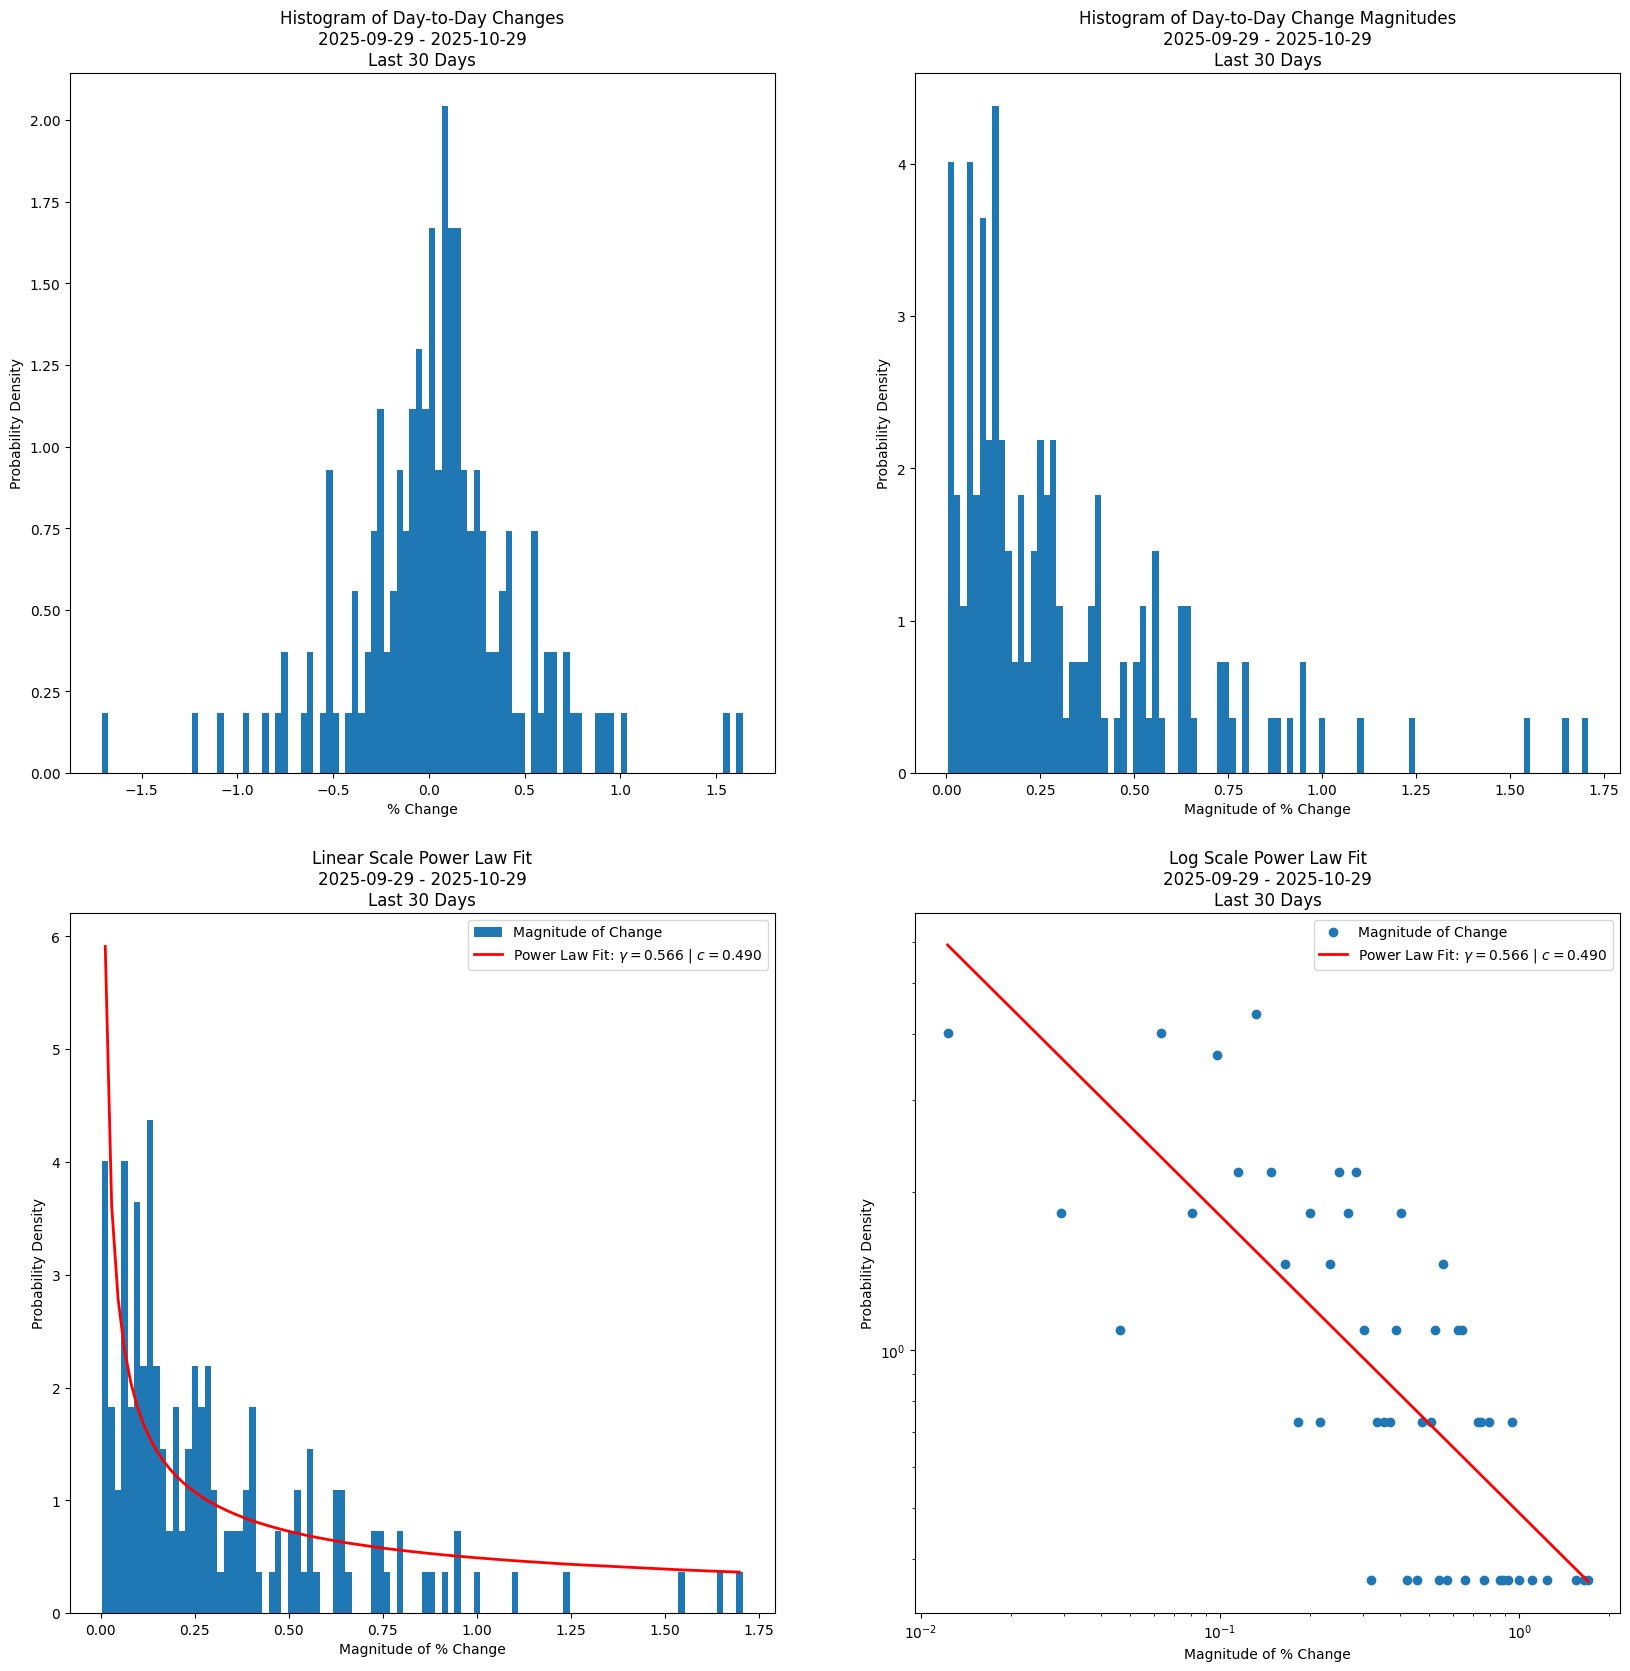

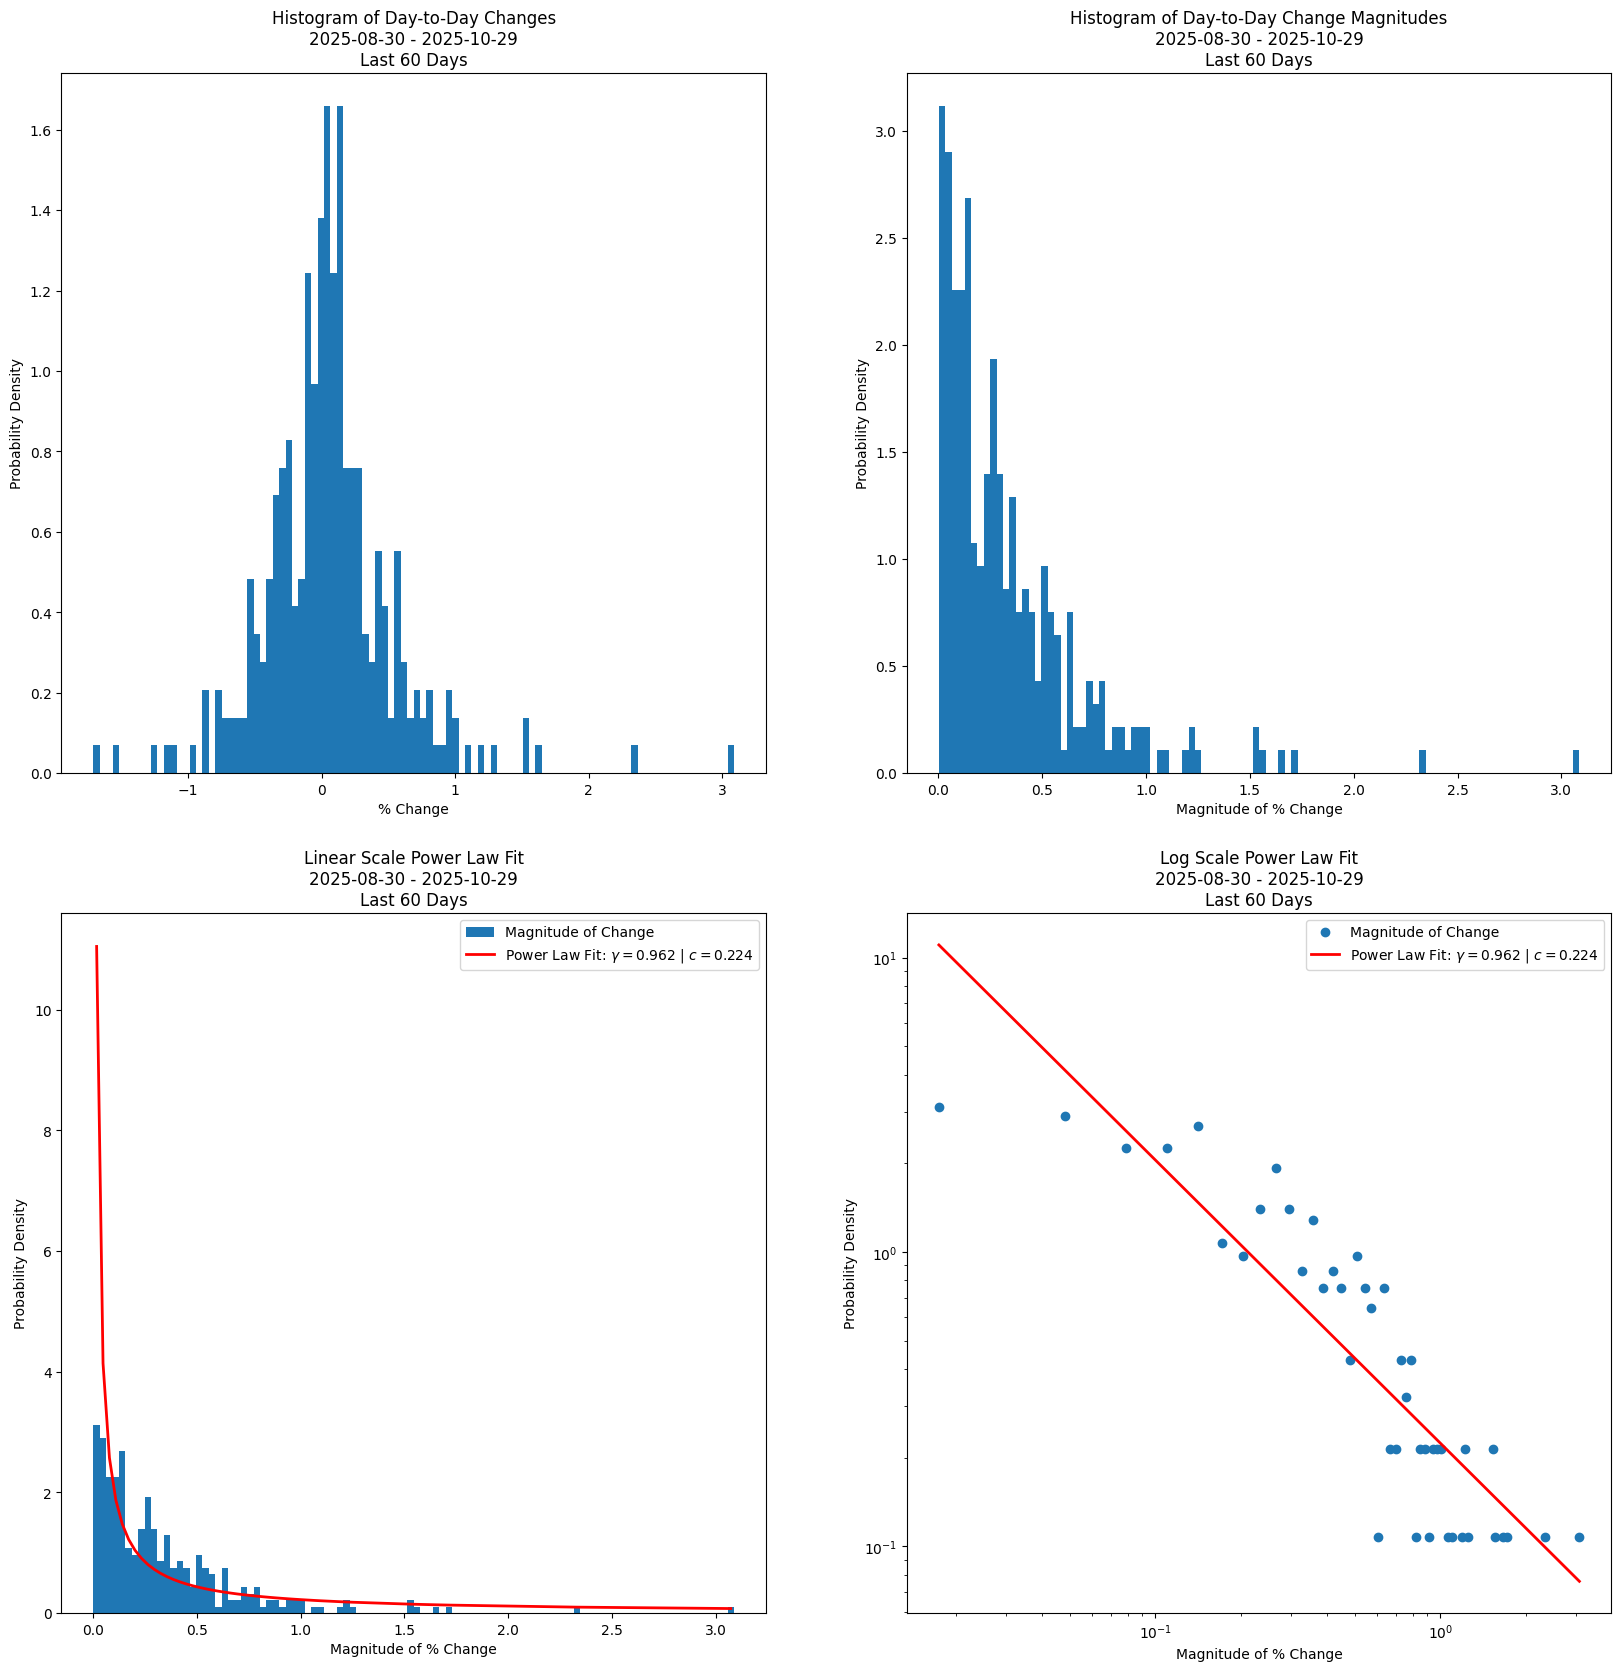

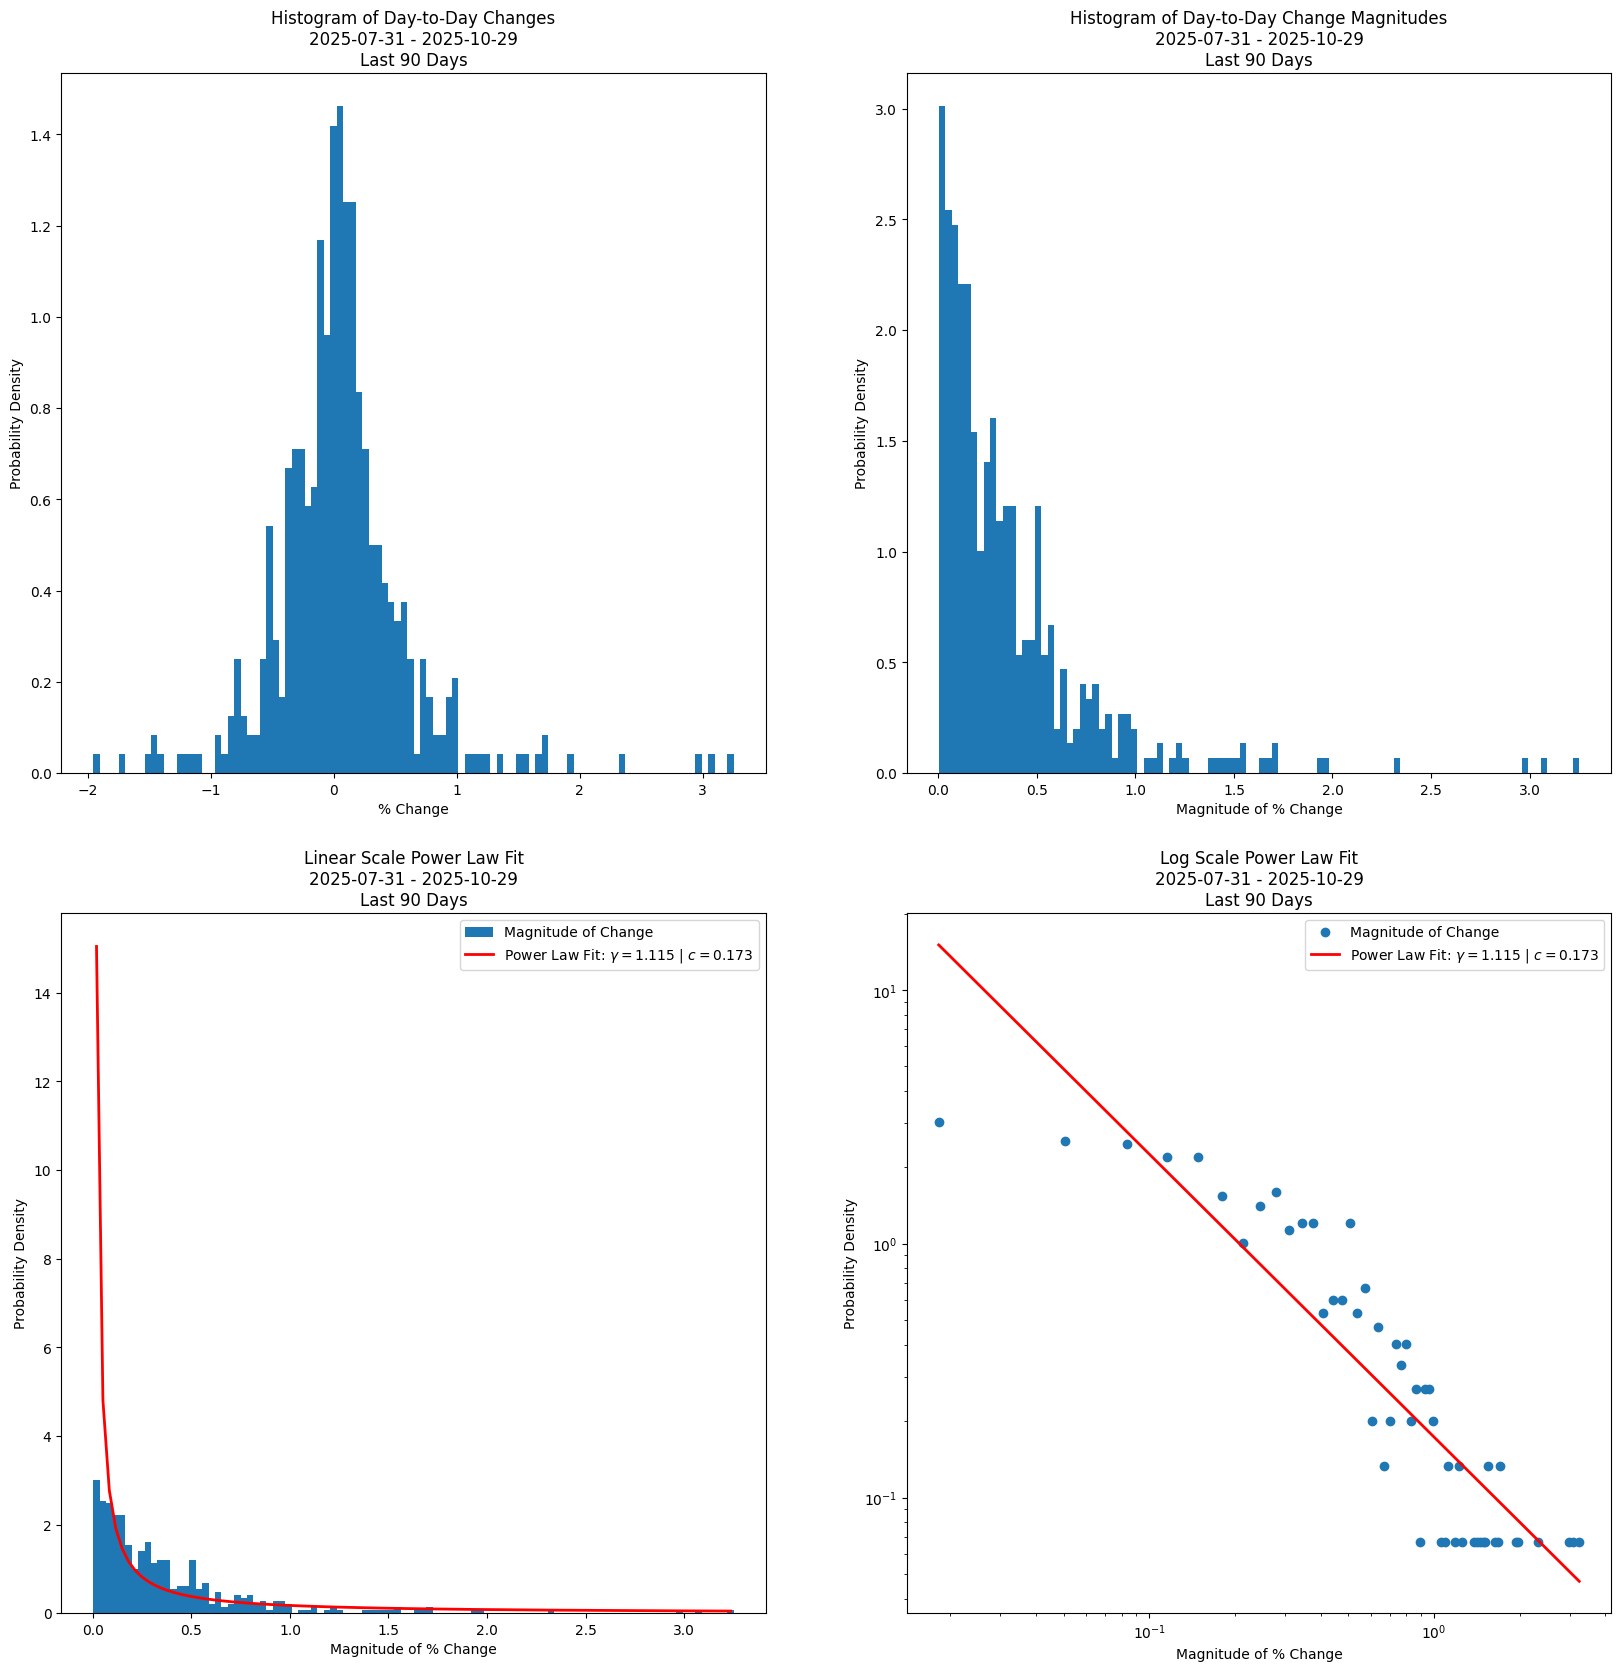

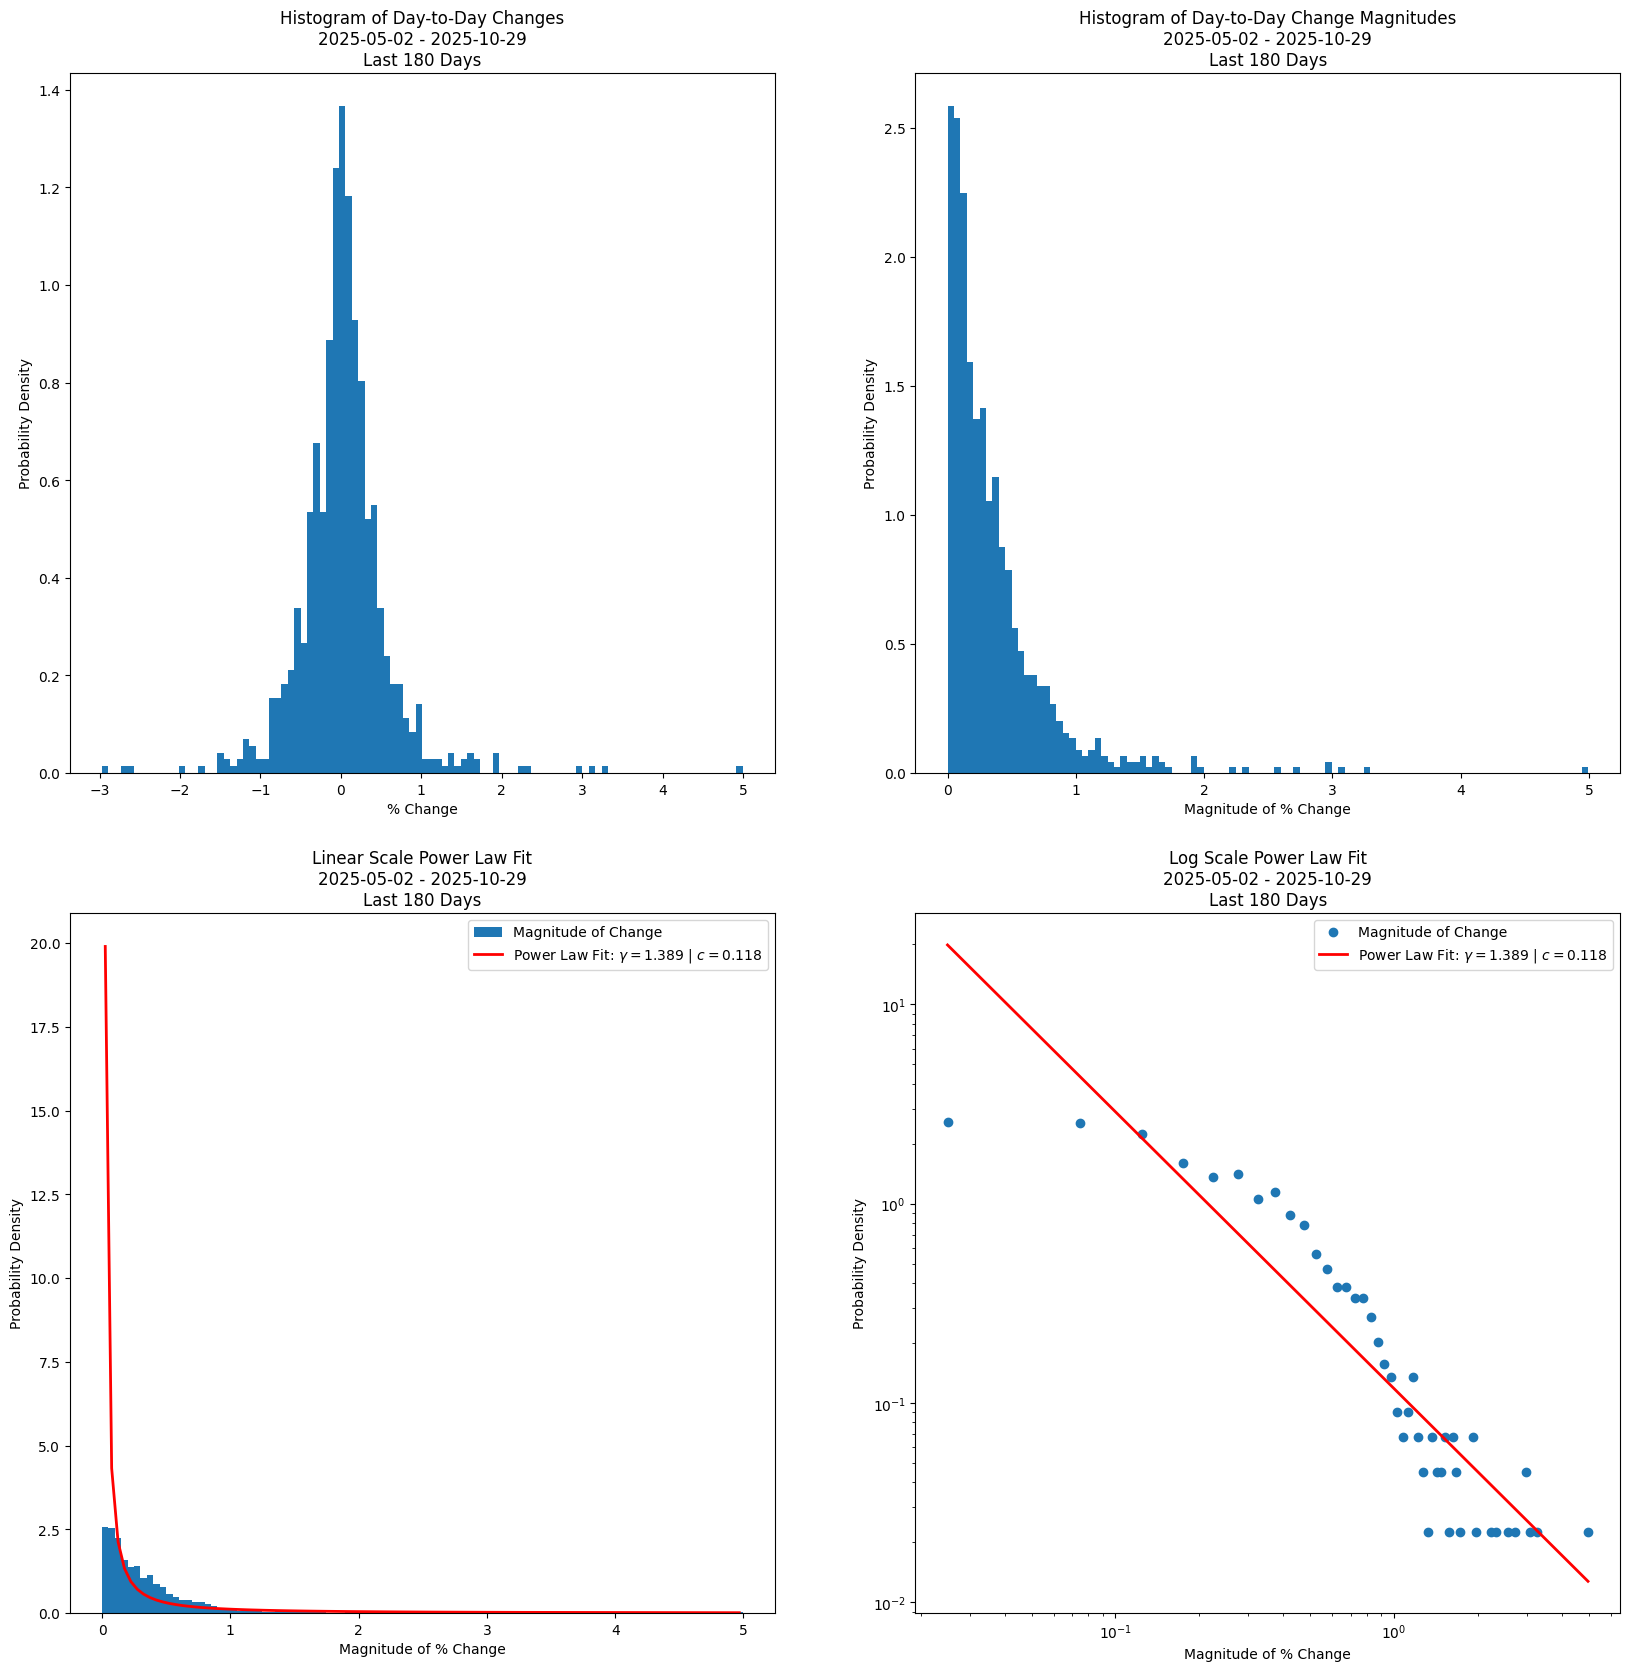

In [59]:
get_historical_magnitude_plots(symbol = 'AAPL',
                                timeframe = '1H',
                                historical_start_date = '2024-01-01',
                                historical_end_date = 'now',
                                day_offsets = [10, 30, 60, 90, 180])

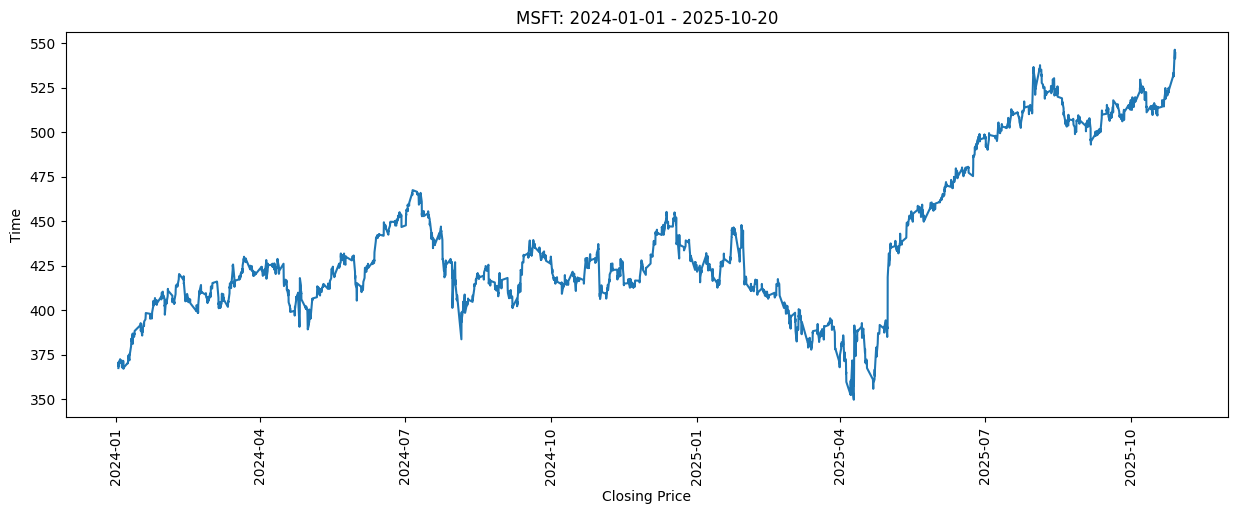

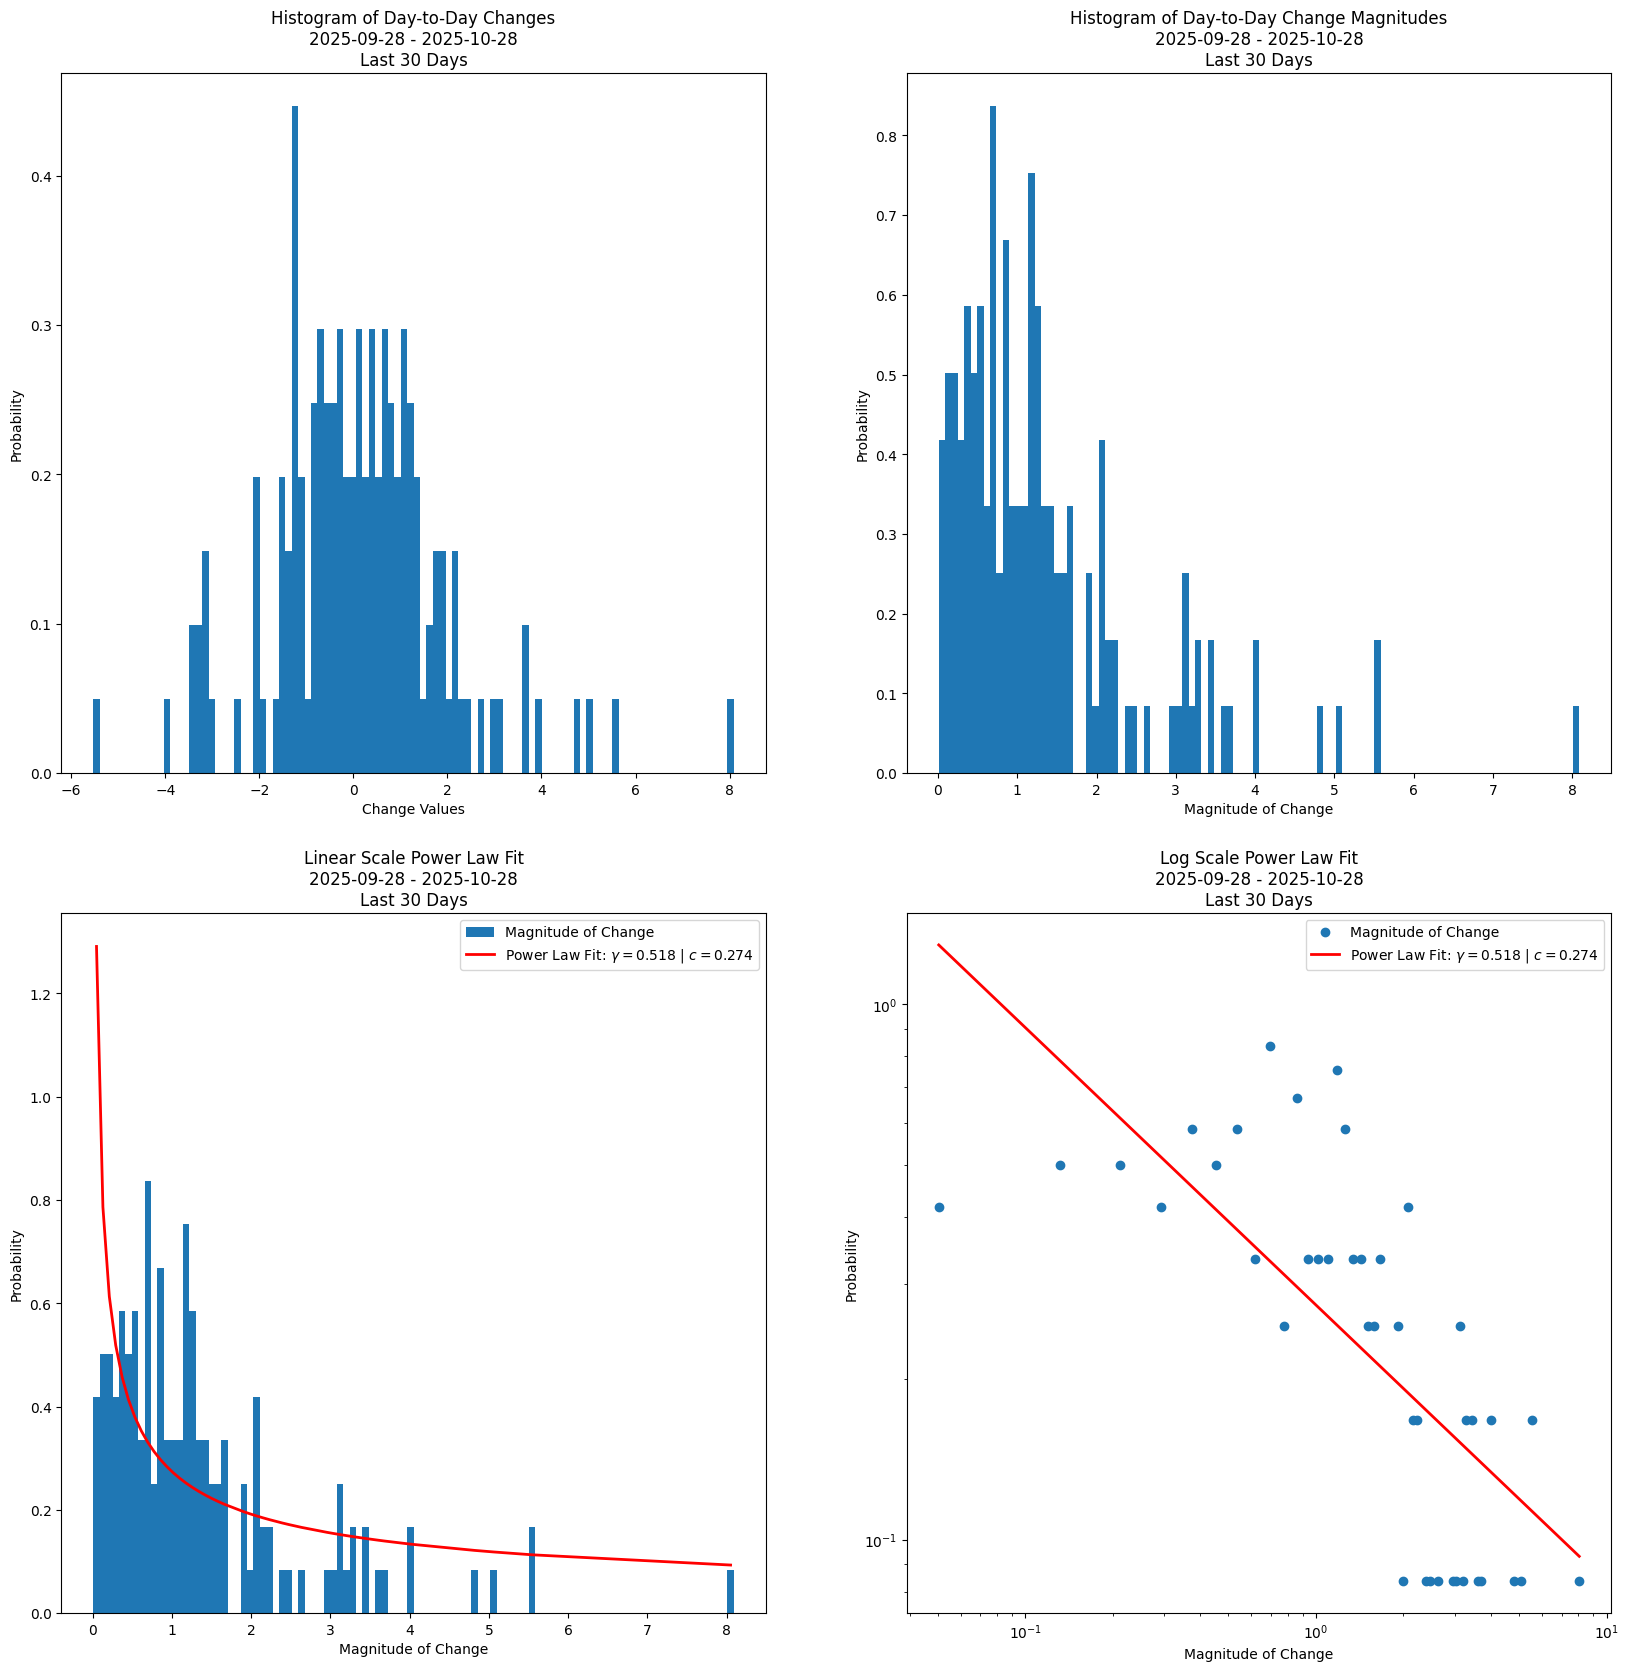

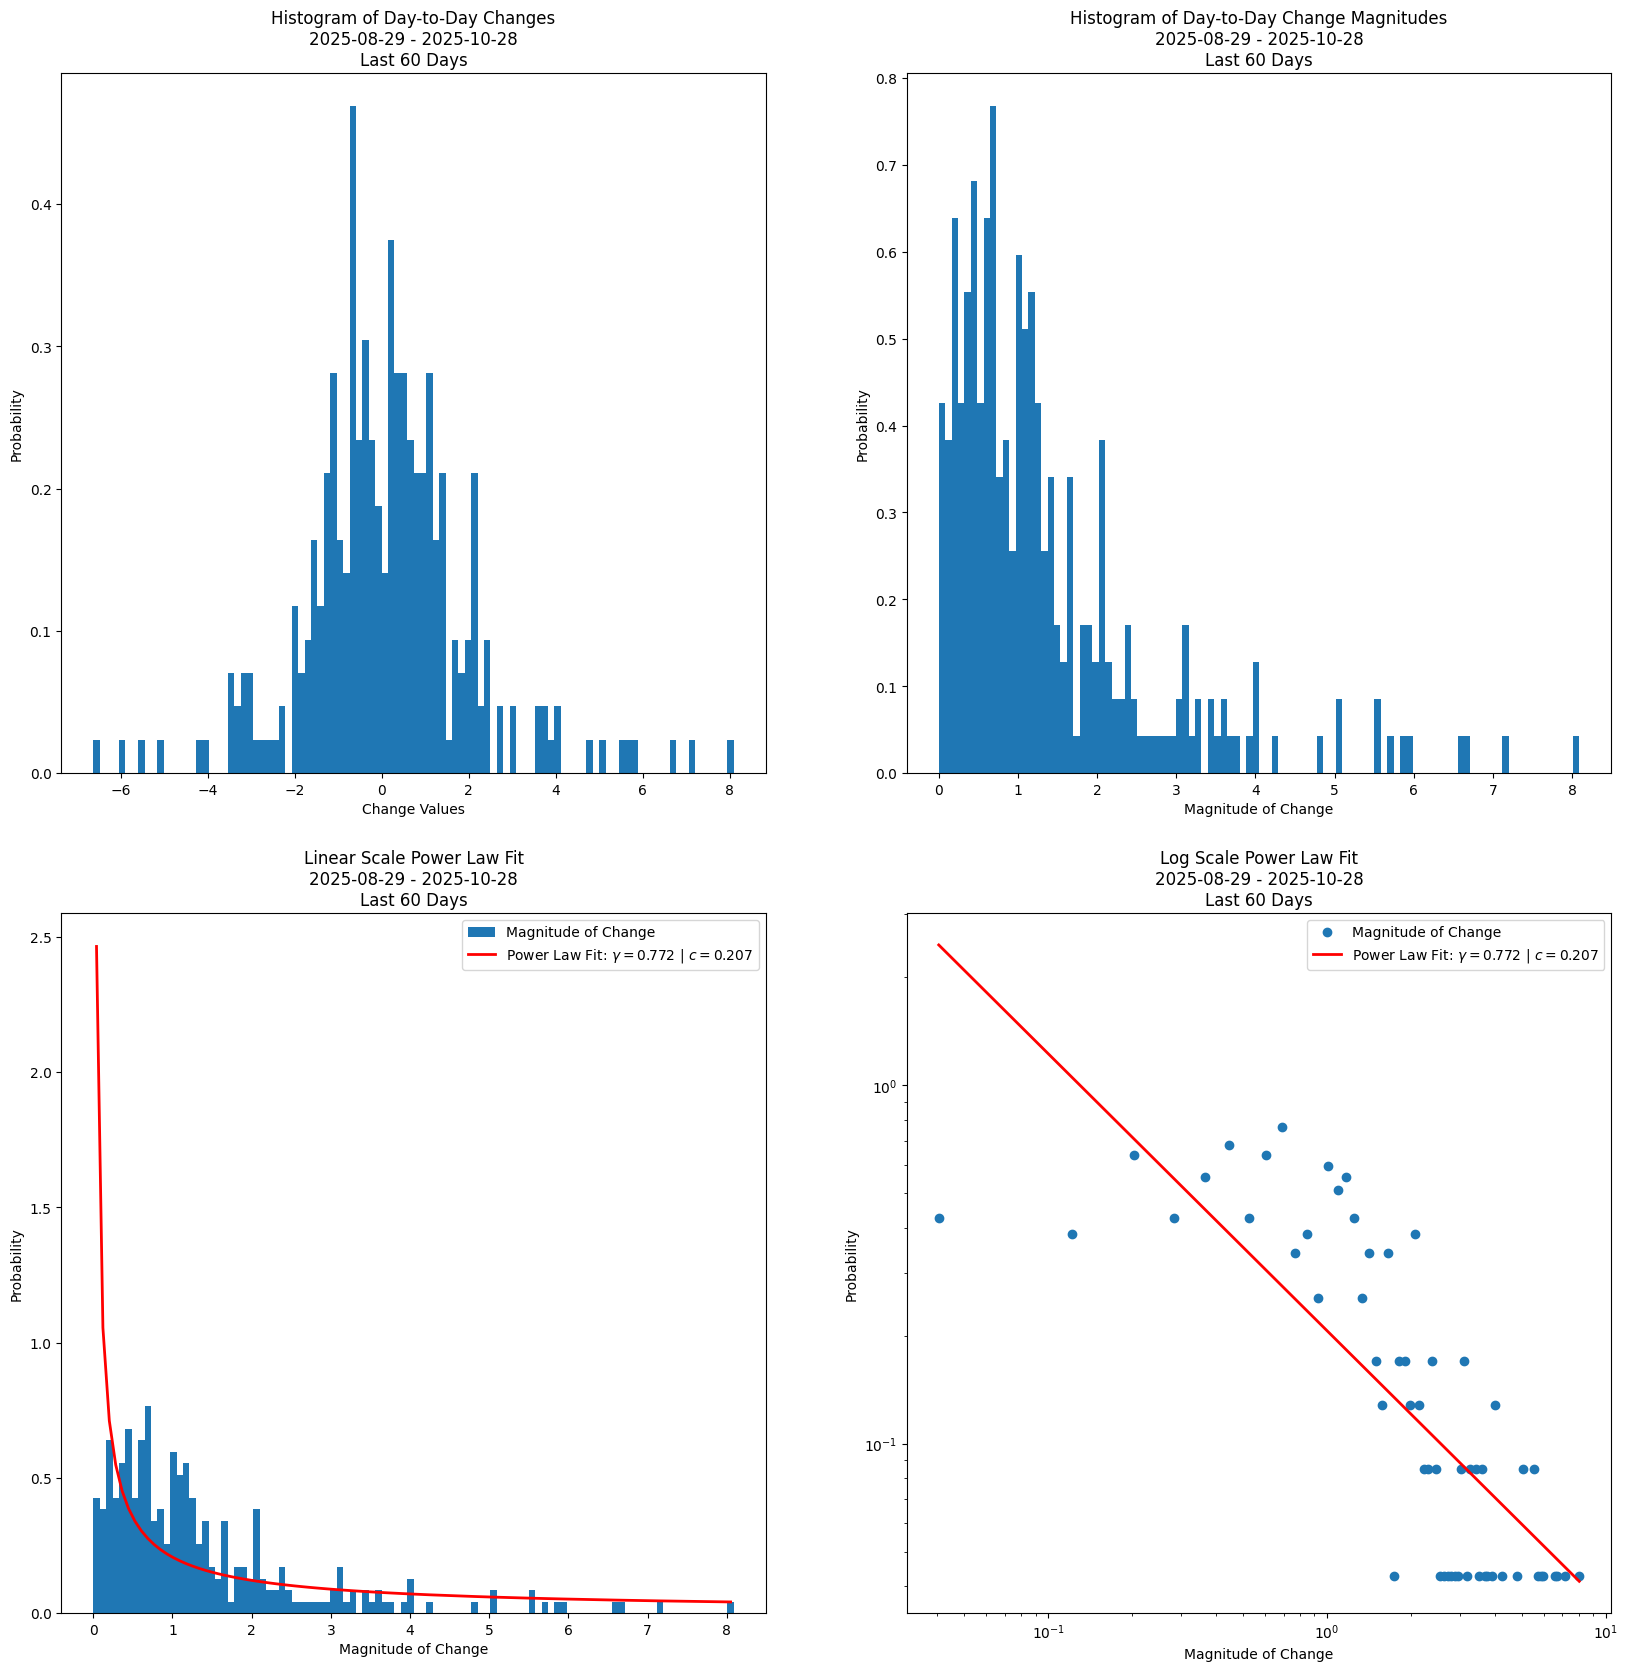

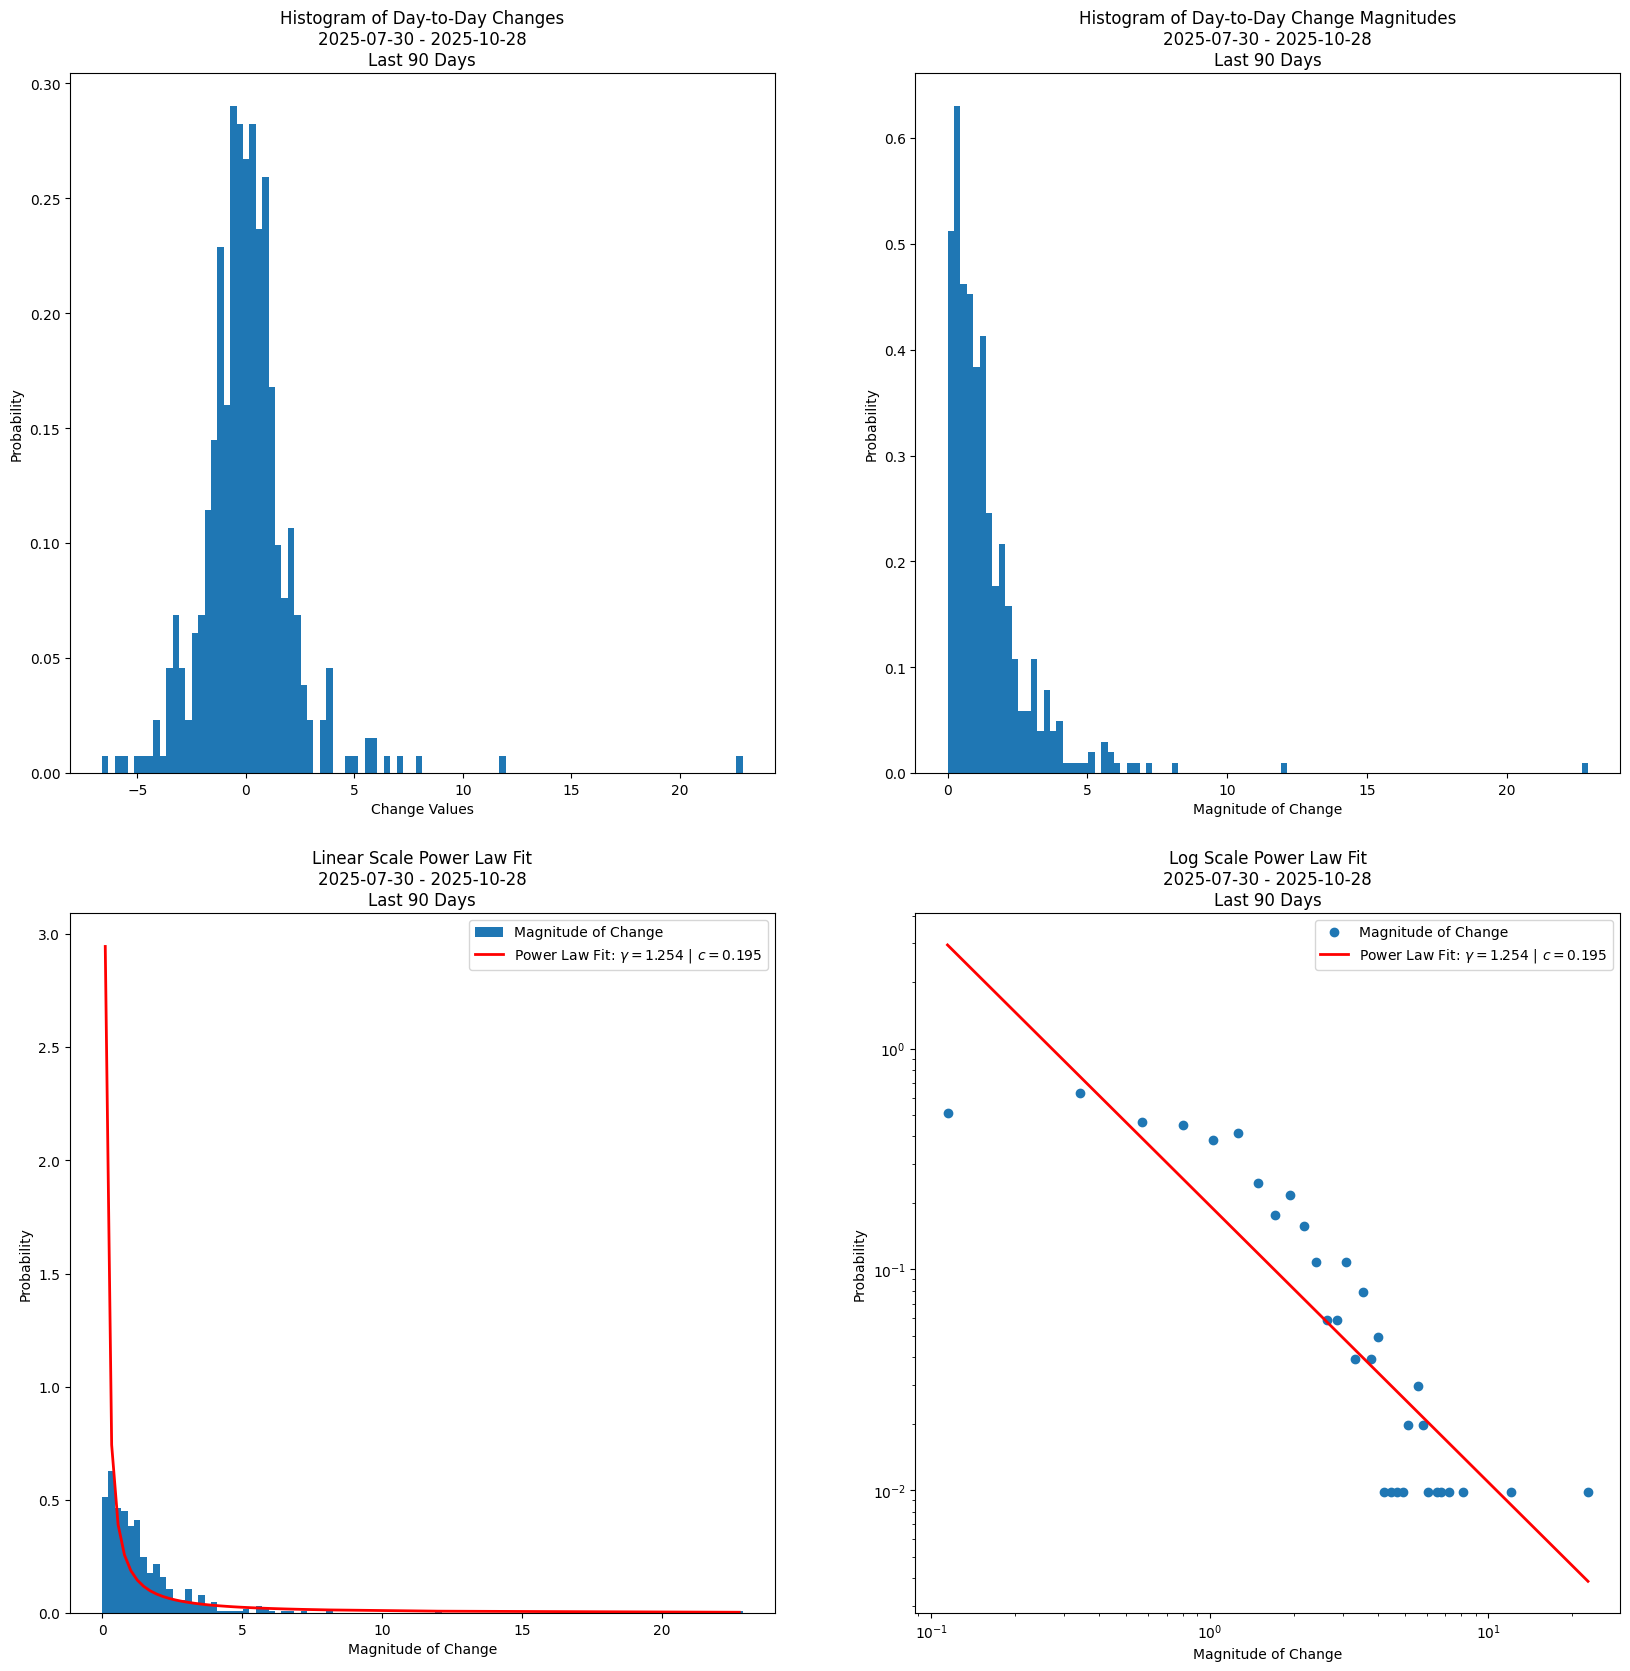

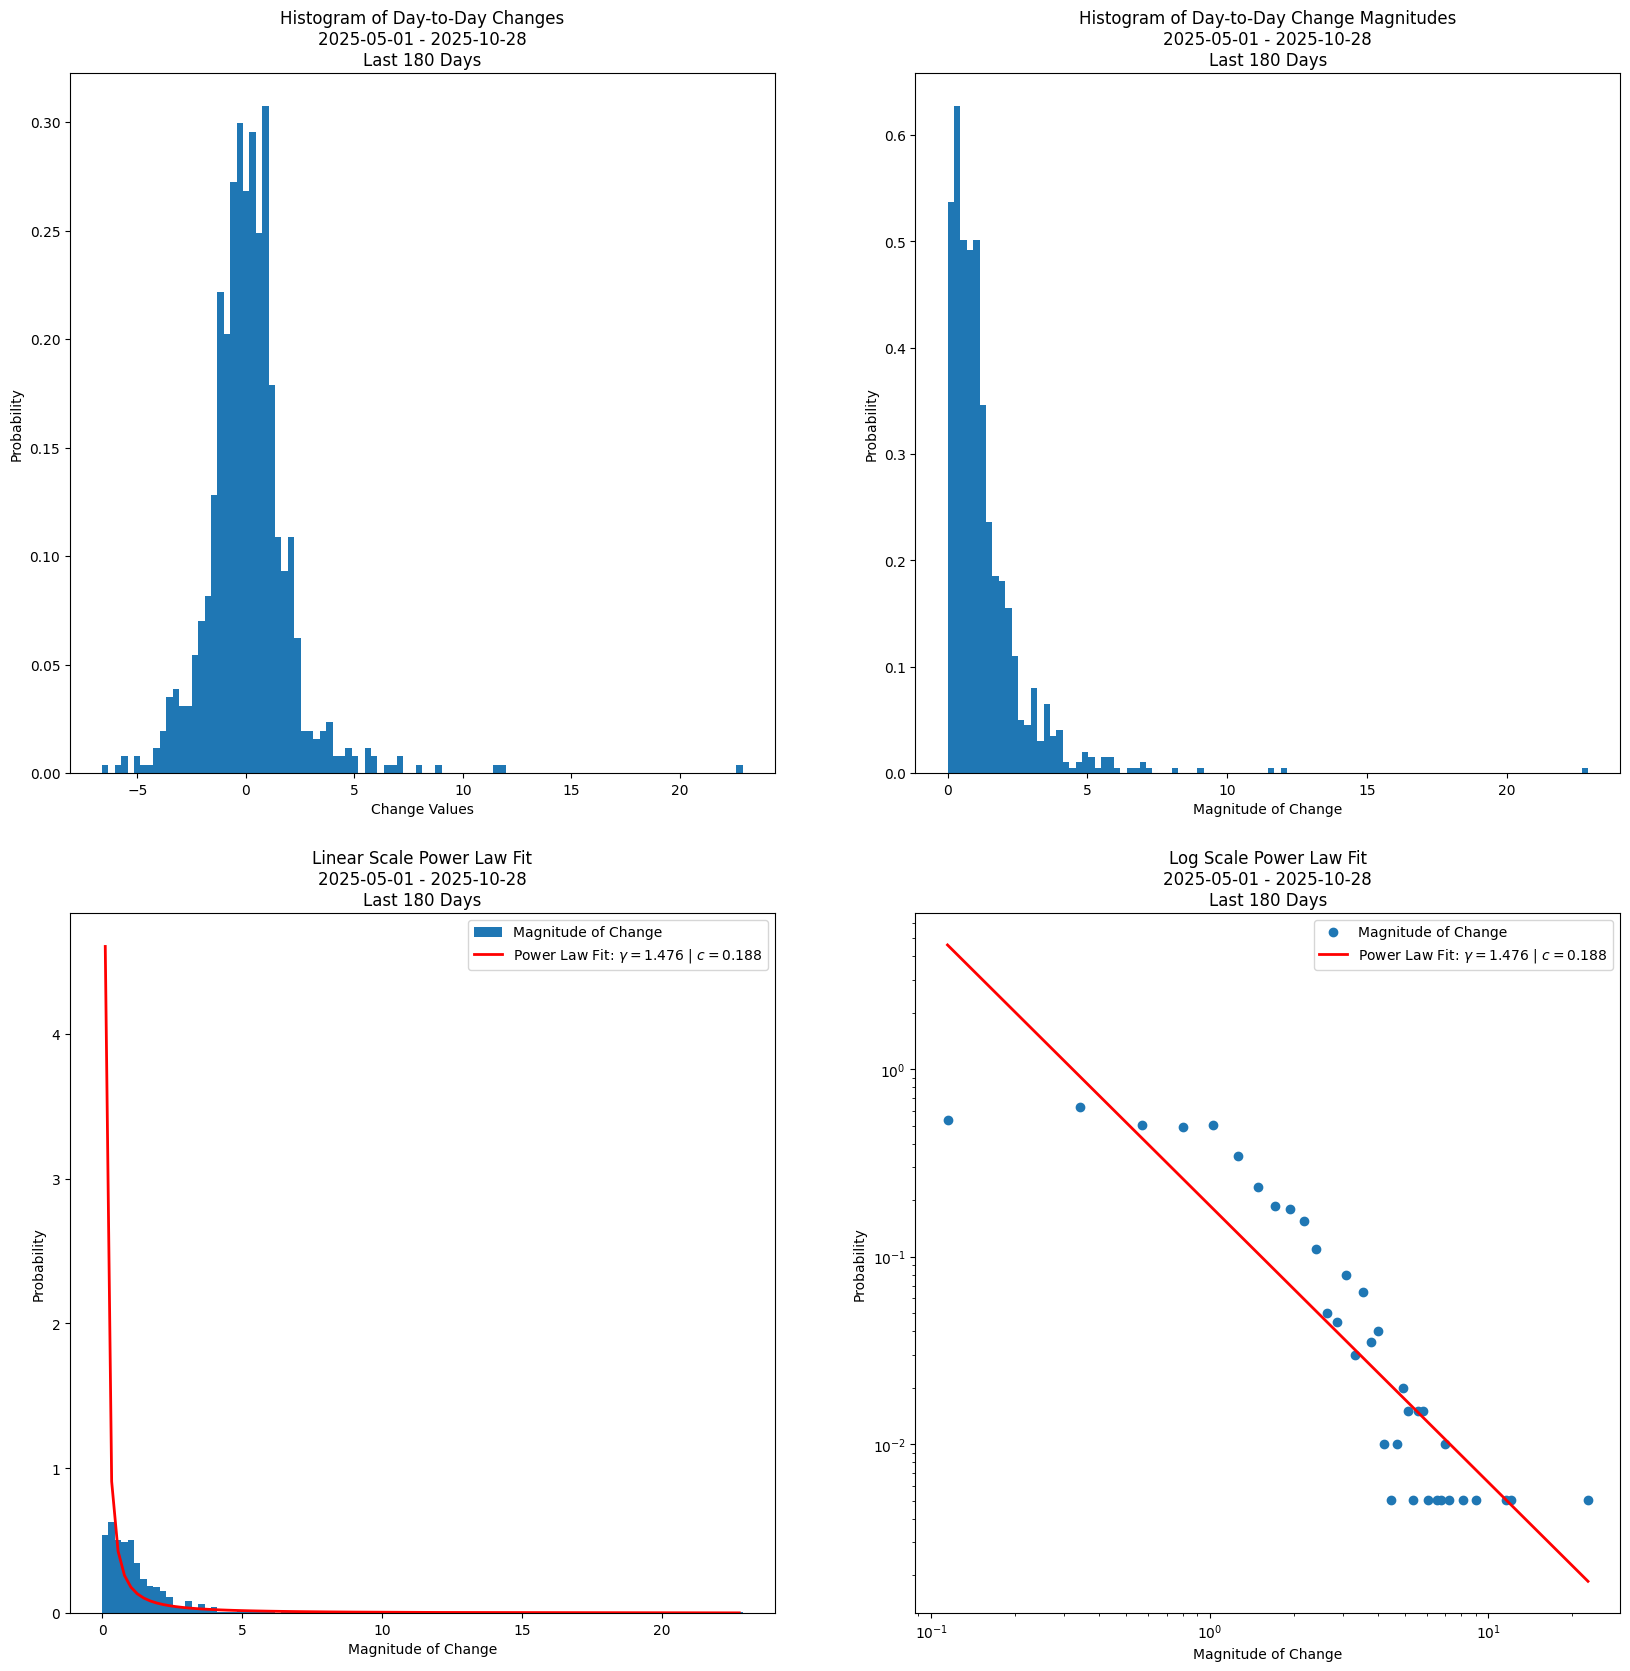

In [34]:
get_historical_magnitude_plots(symbol = 'MSFT',
                                timeframe = '1H',
                                historical_start_date = '2024-01-01',
                                historical_end_date = 'now',
                                day_offsets = [30, 60, 90, 180])

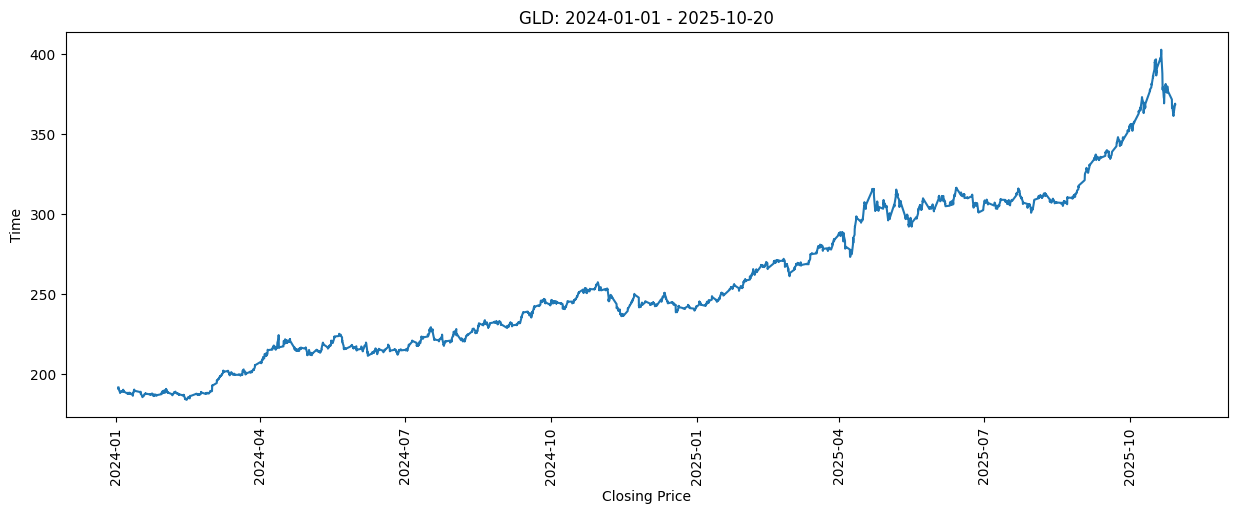

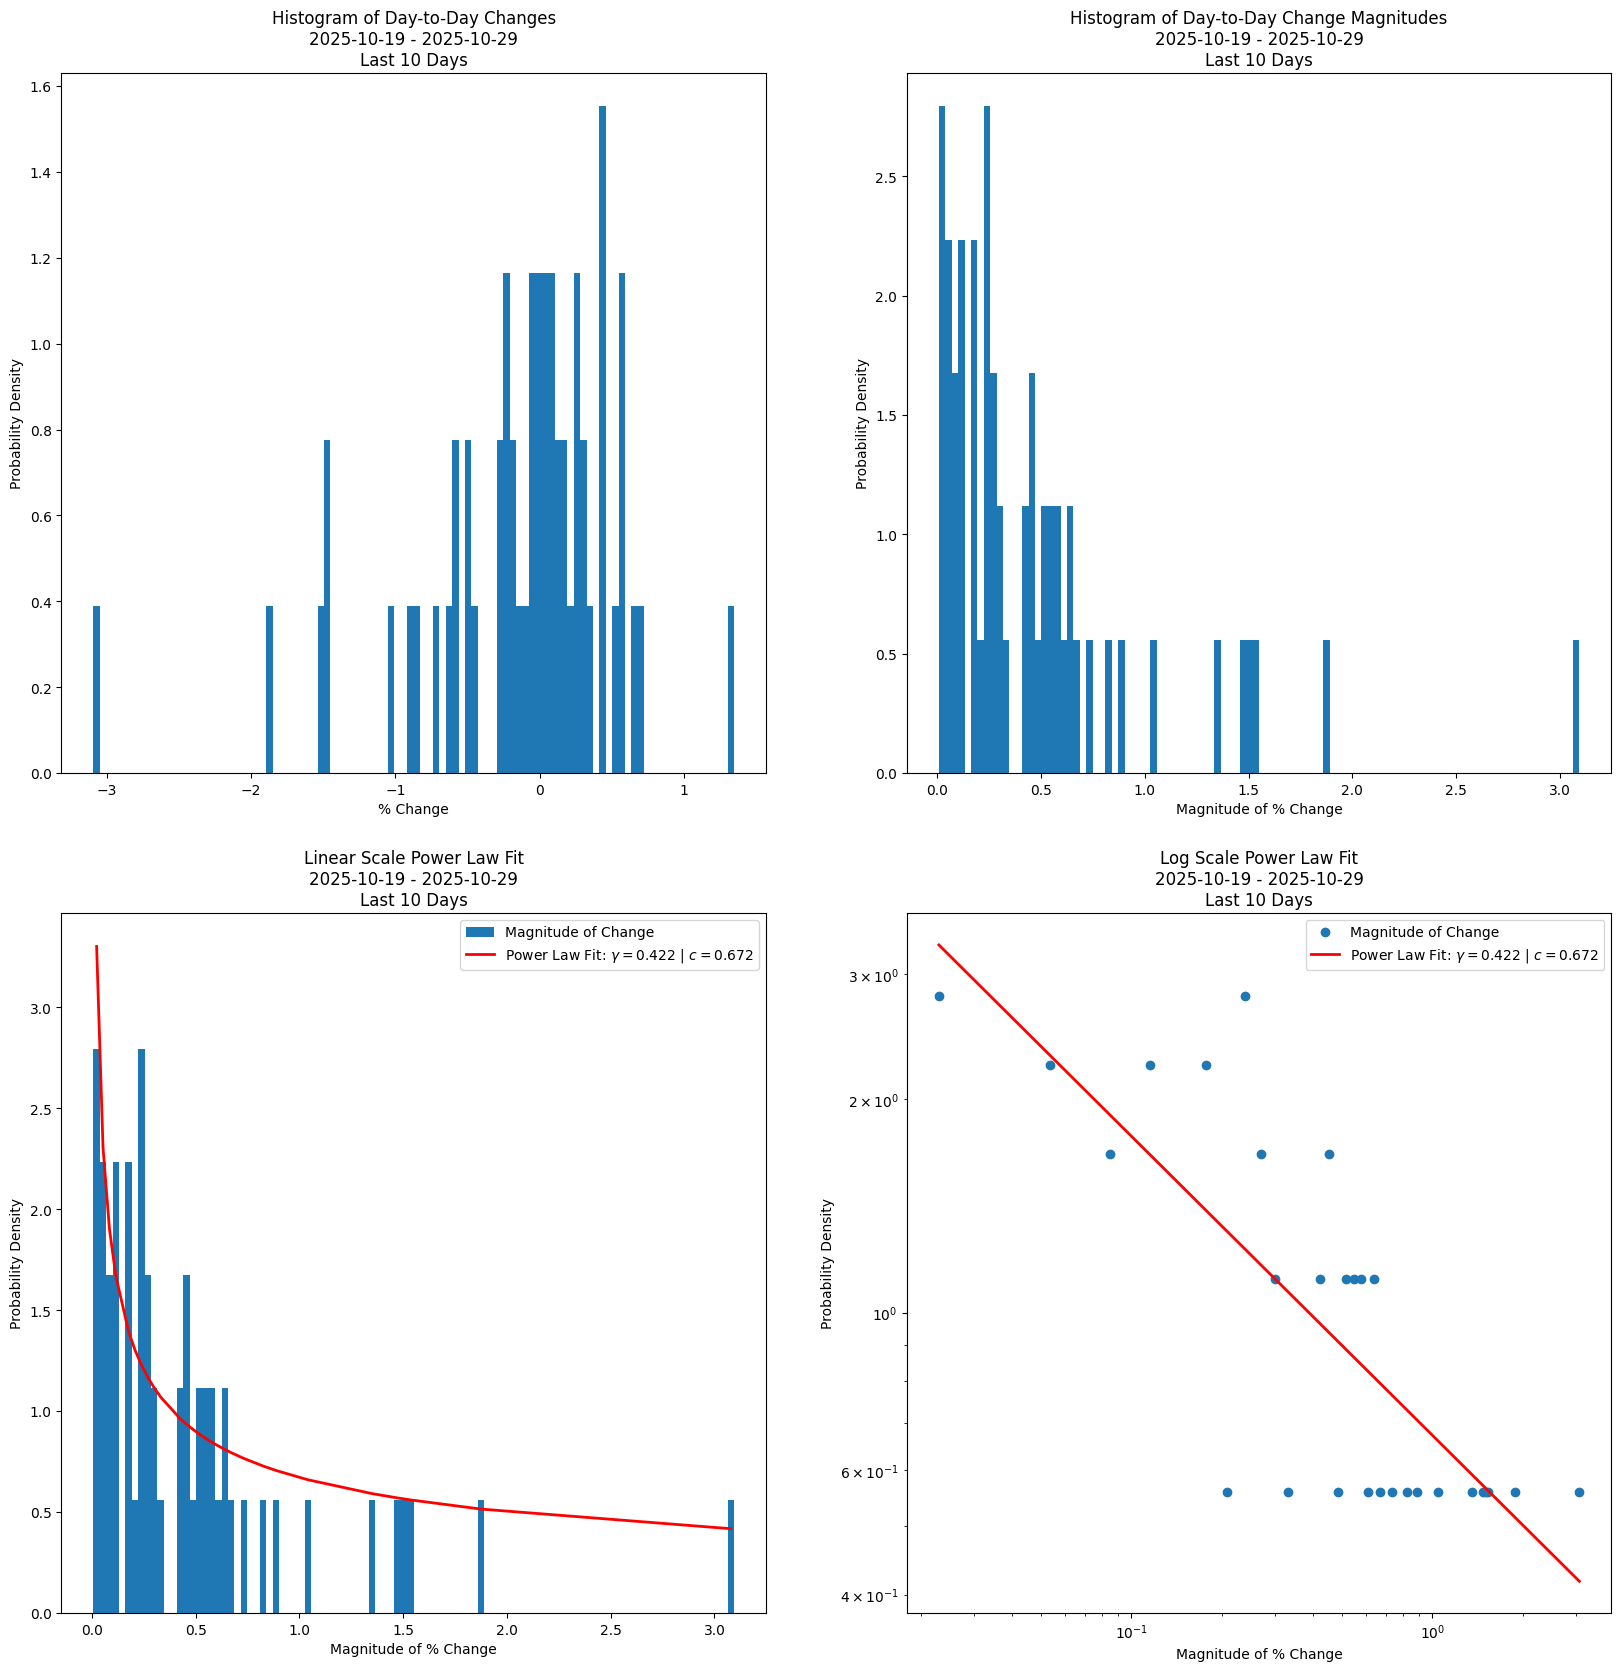

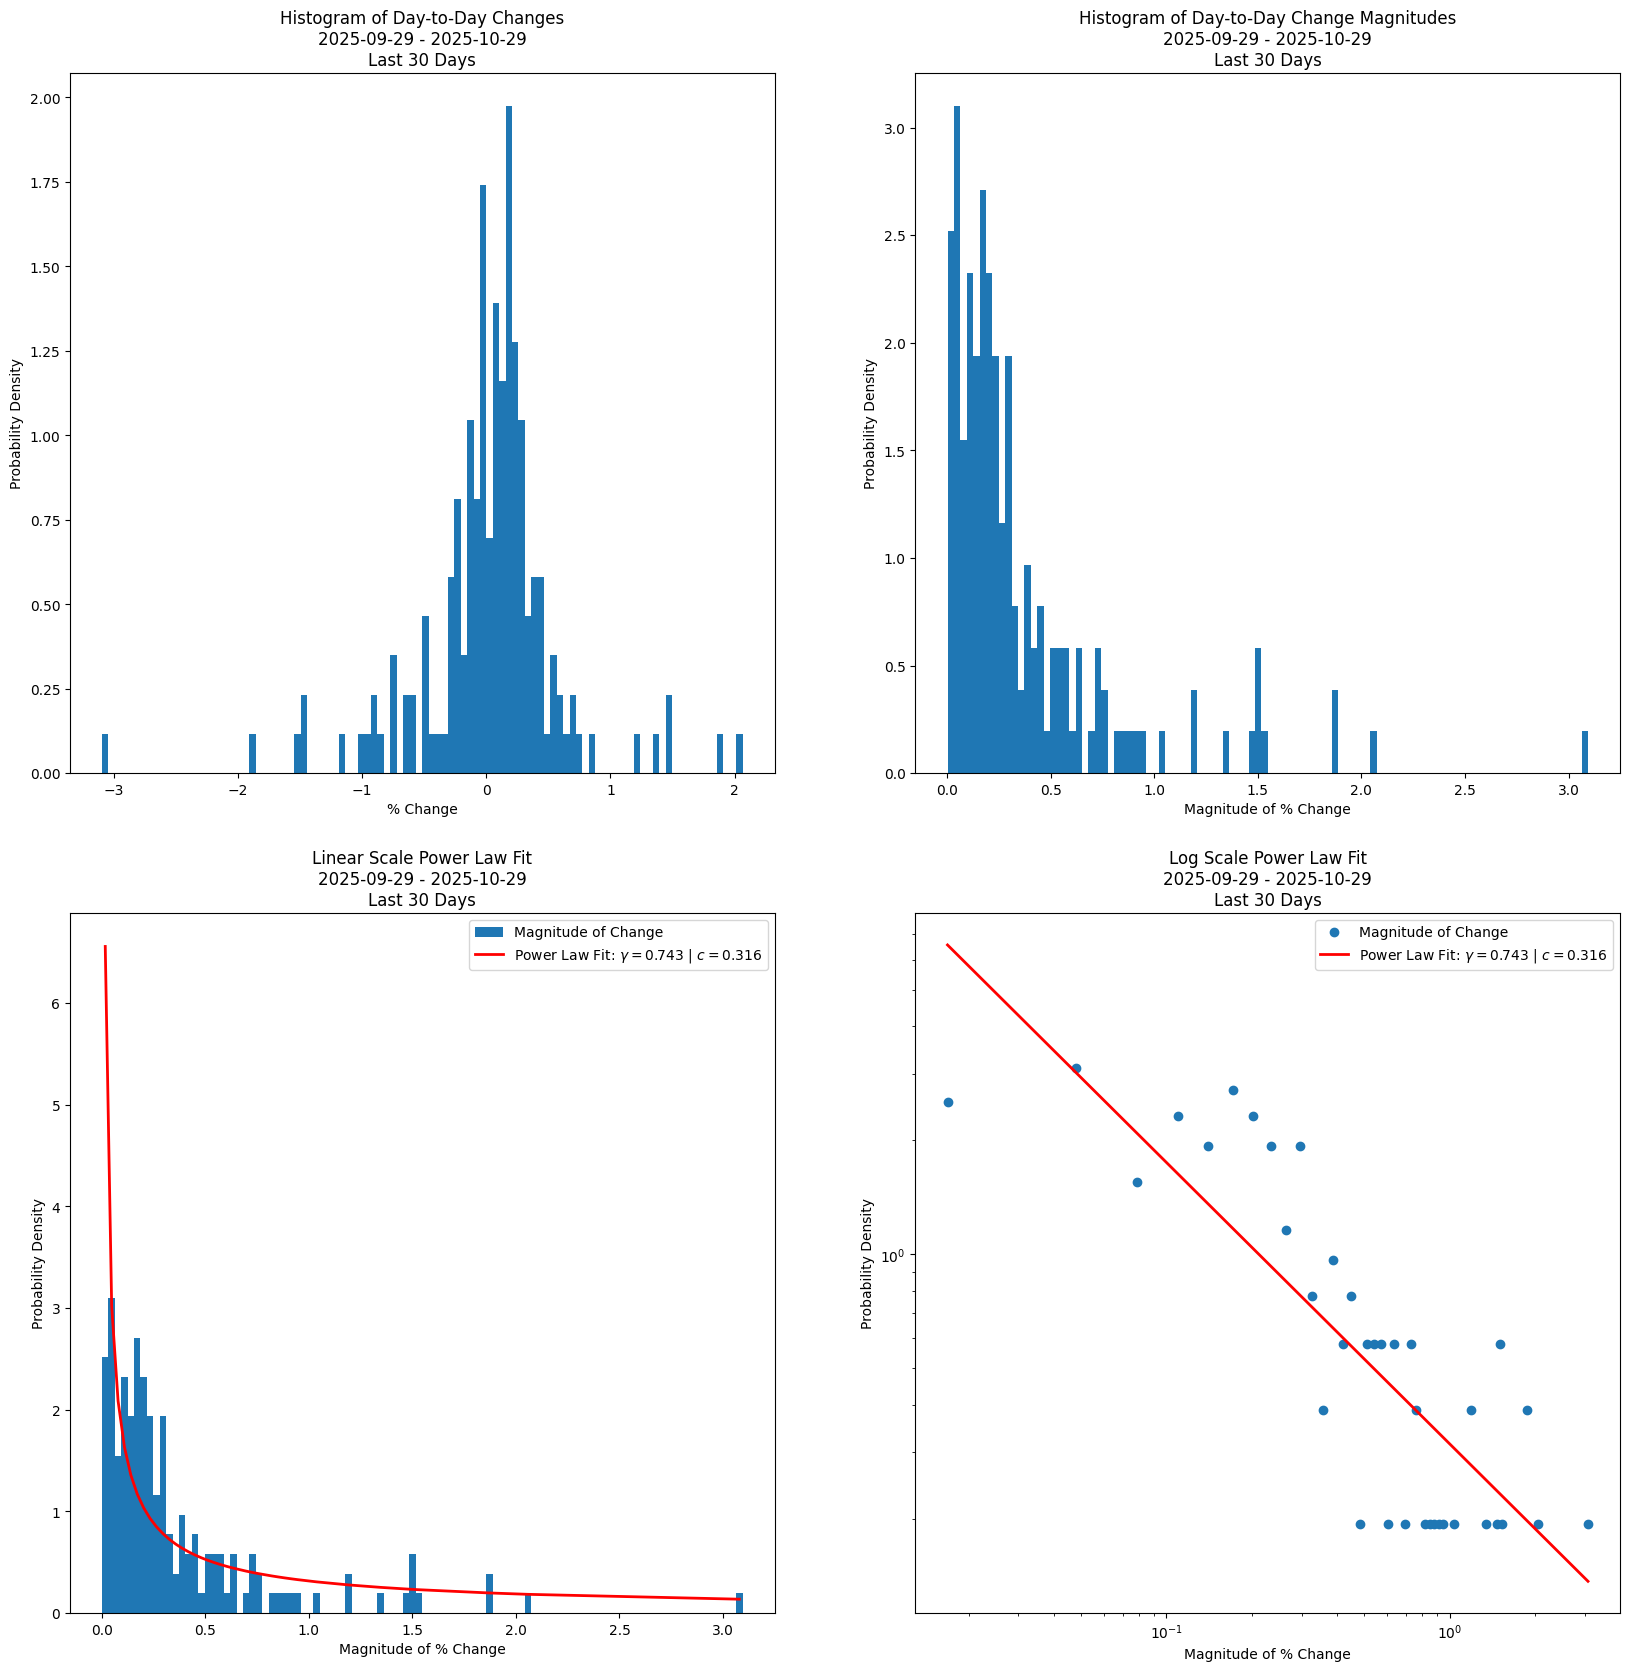

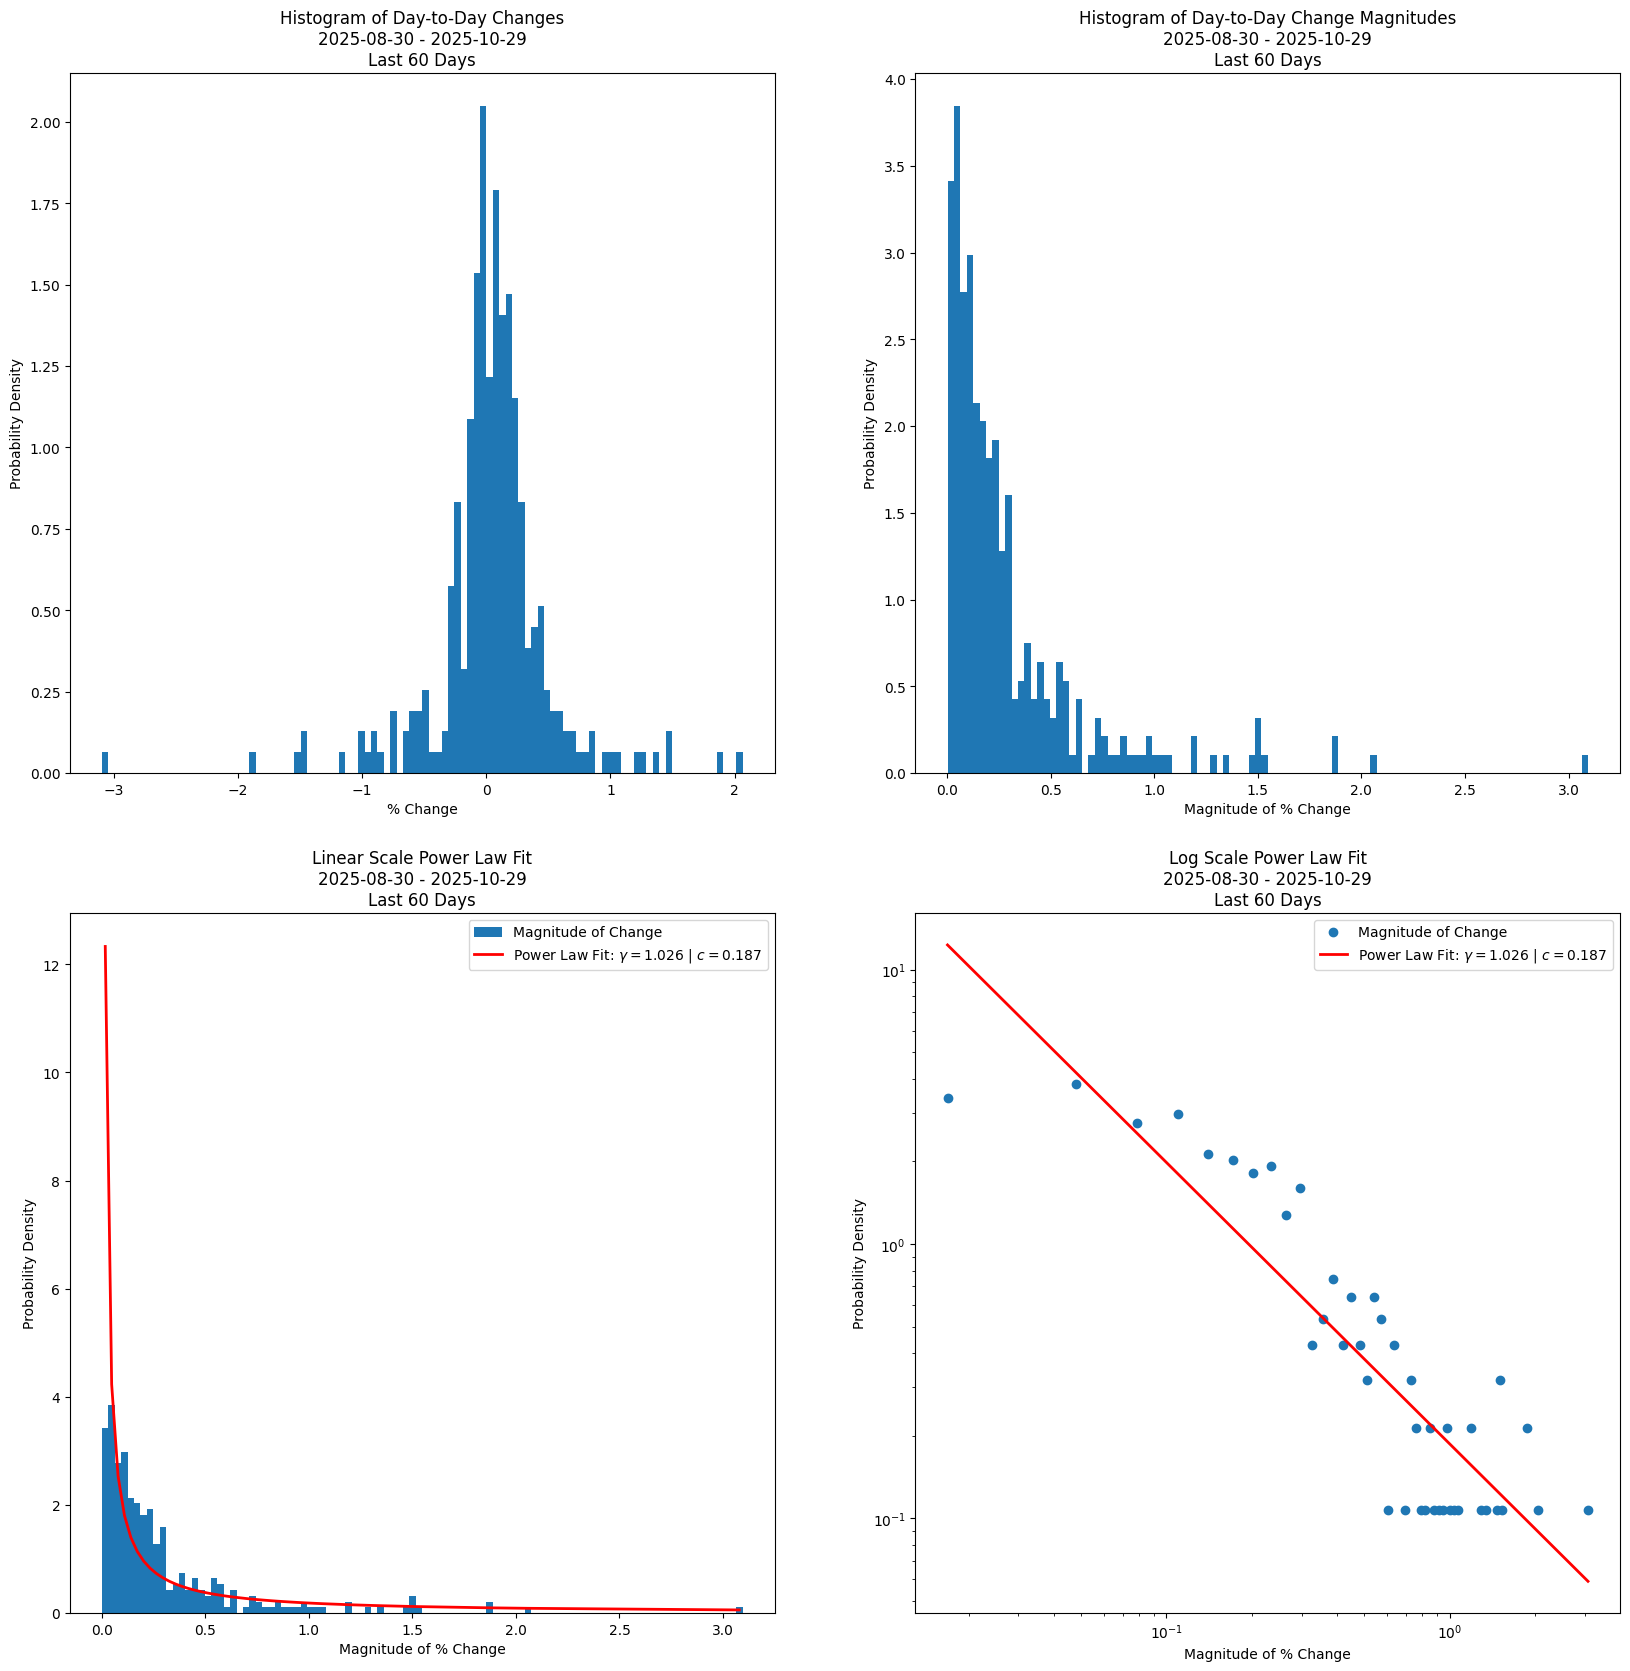

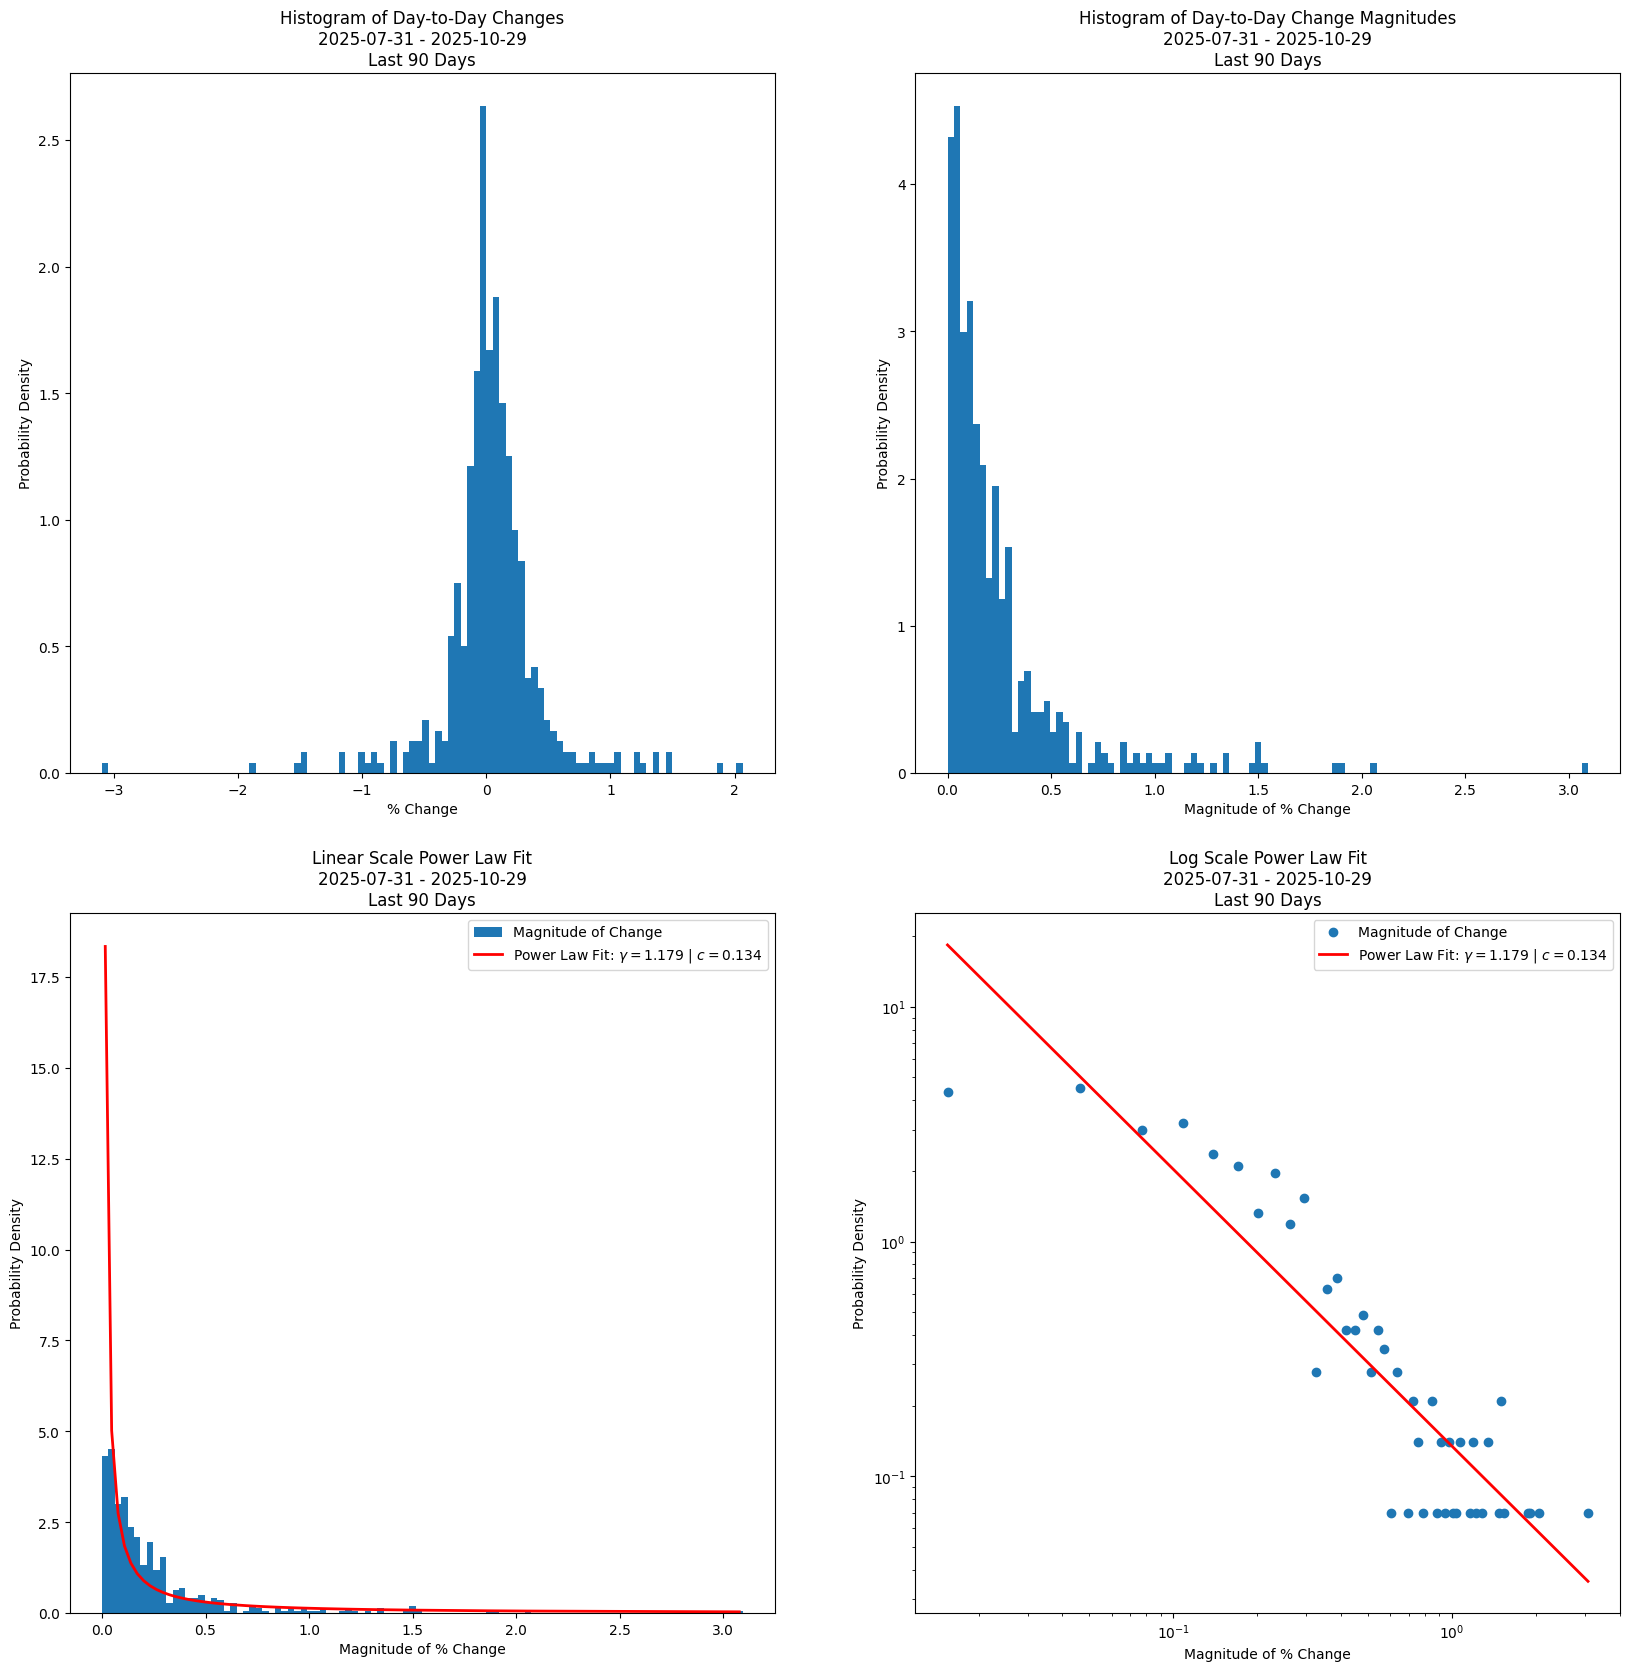

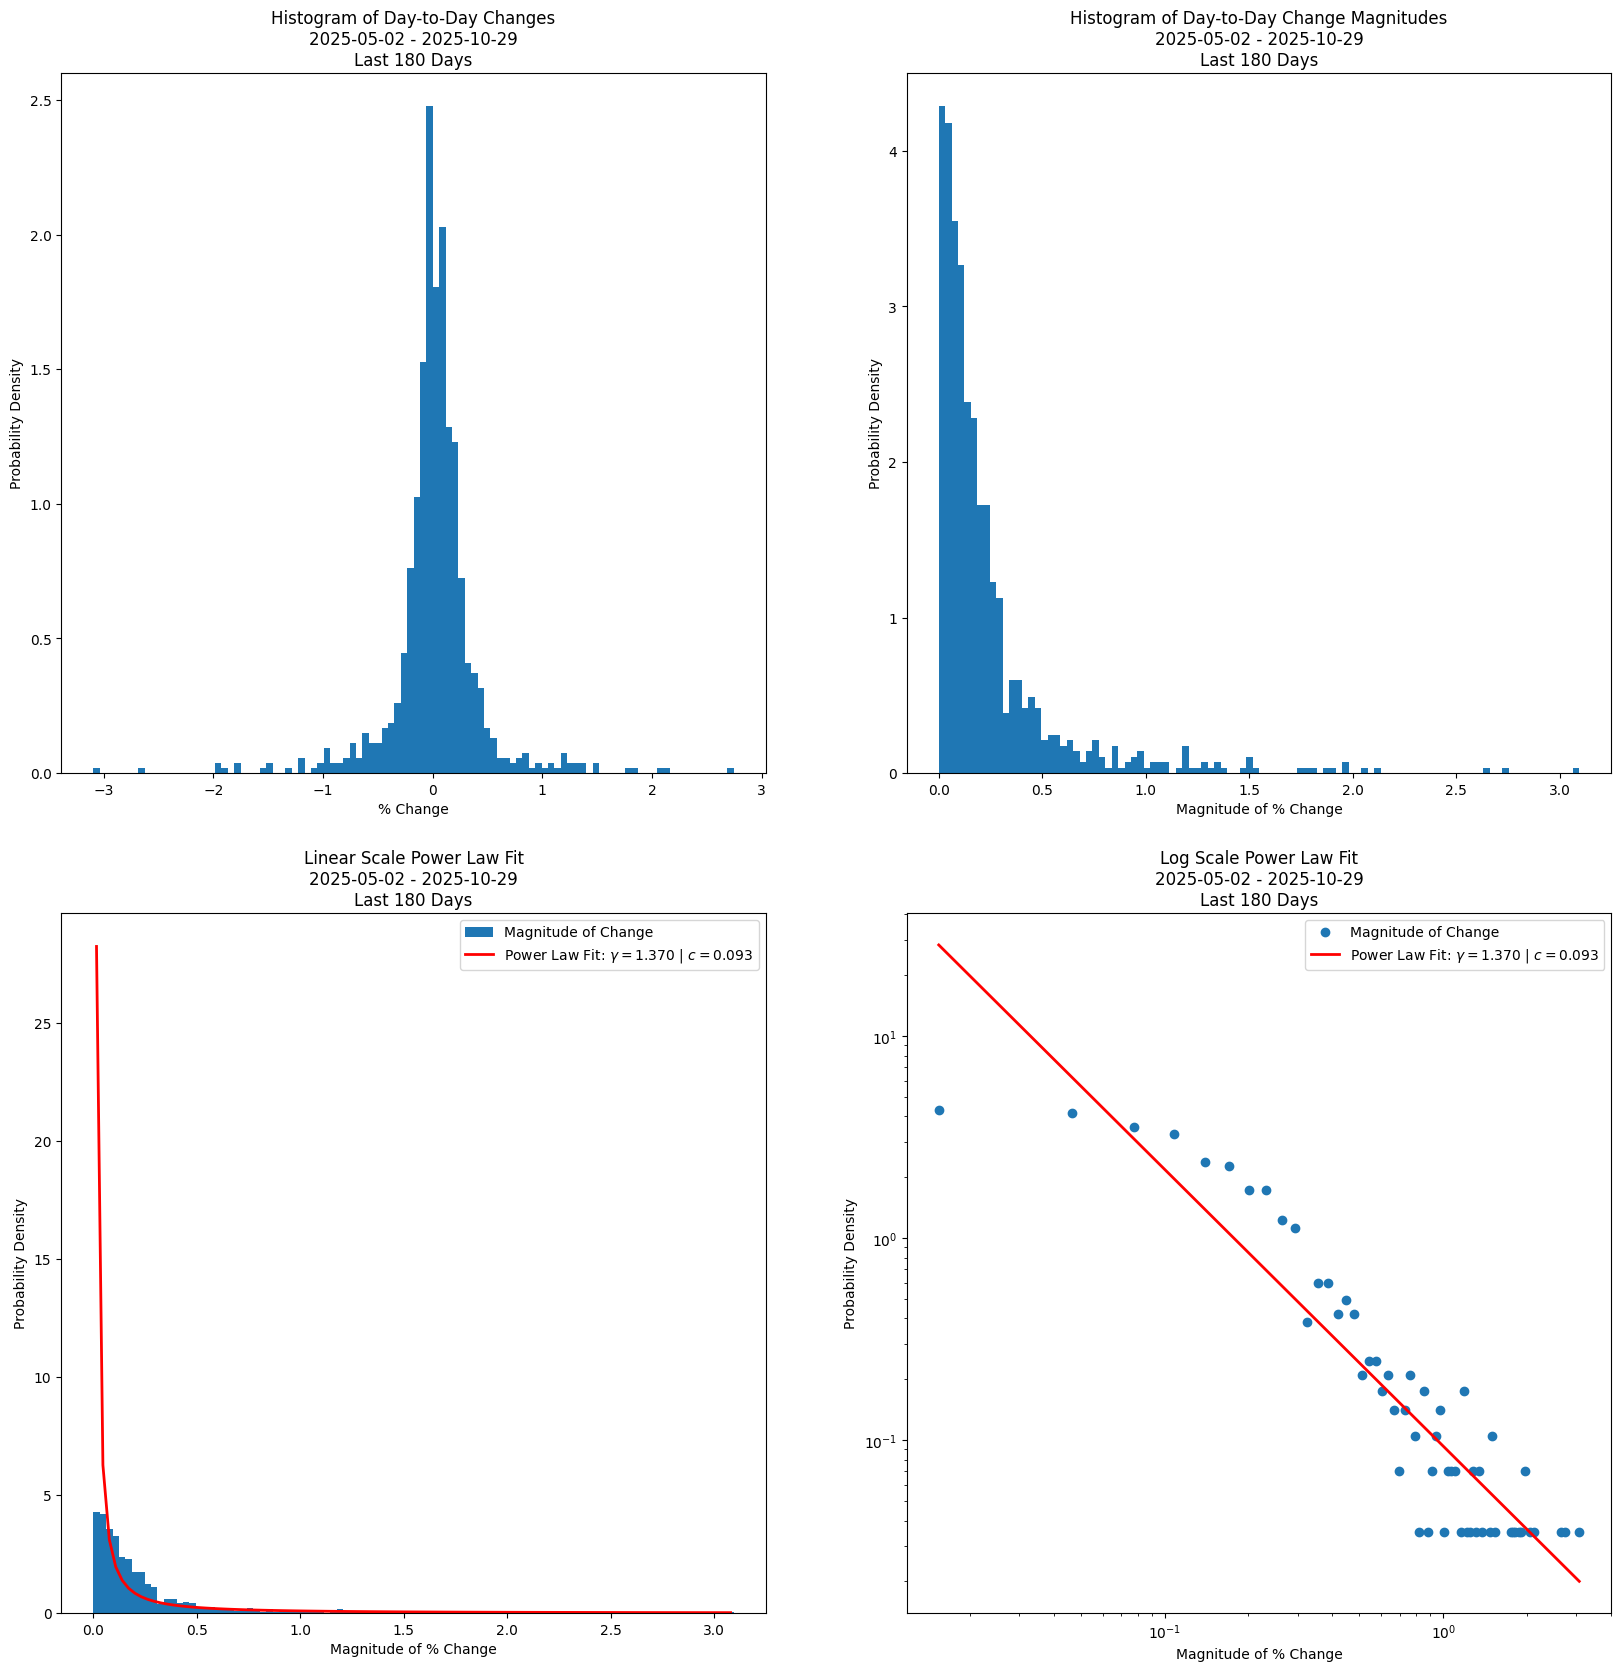

In [56]:
get_historical_magnitude_plots(symbol = 'GLD',
                                timeframe = '1H',
                                historical_start_date = '2024-01-01',
                                historical_end_date = 'now',
                                day_offsets = [10, 30, 60, 90, 180])

# Backtest - Options

100%|██████████| 213/213 [04:48<00:00,  1.35s/it]


Total Trades: 1531
Total P&L: $-987751.00
Win Rate: 29.78%
Average P&L: $-645.17
--- Reconciliation ---
Final Value (+ idle):   $15,664.00
Expected Final Value:   $15,664.00
Difference:             $0.00


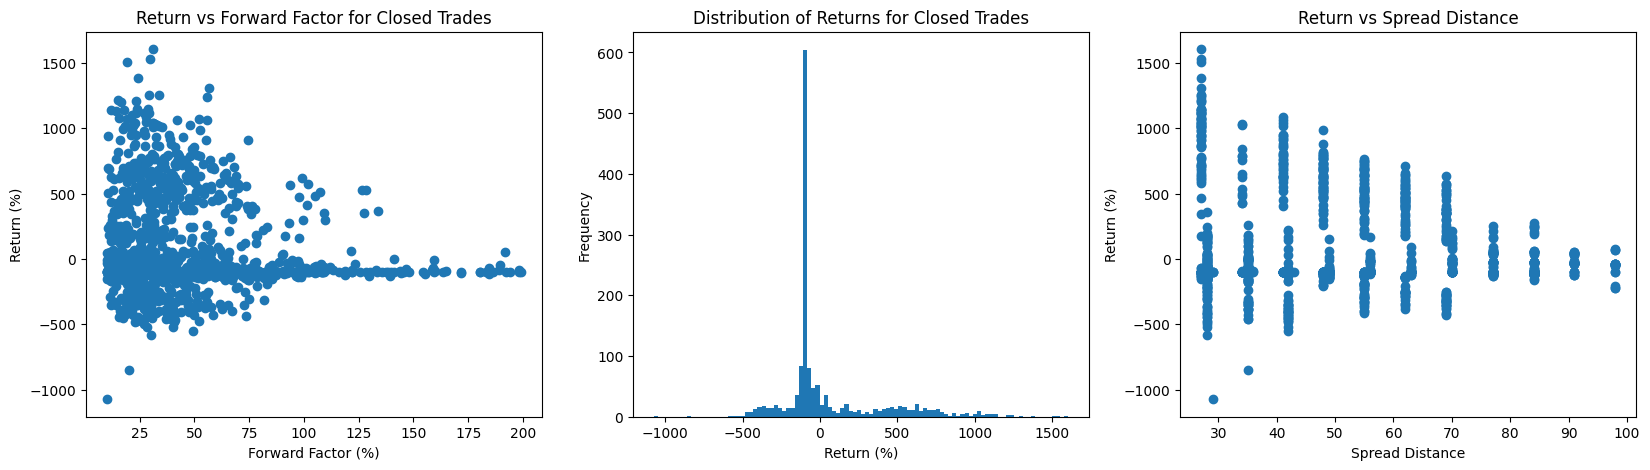

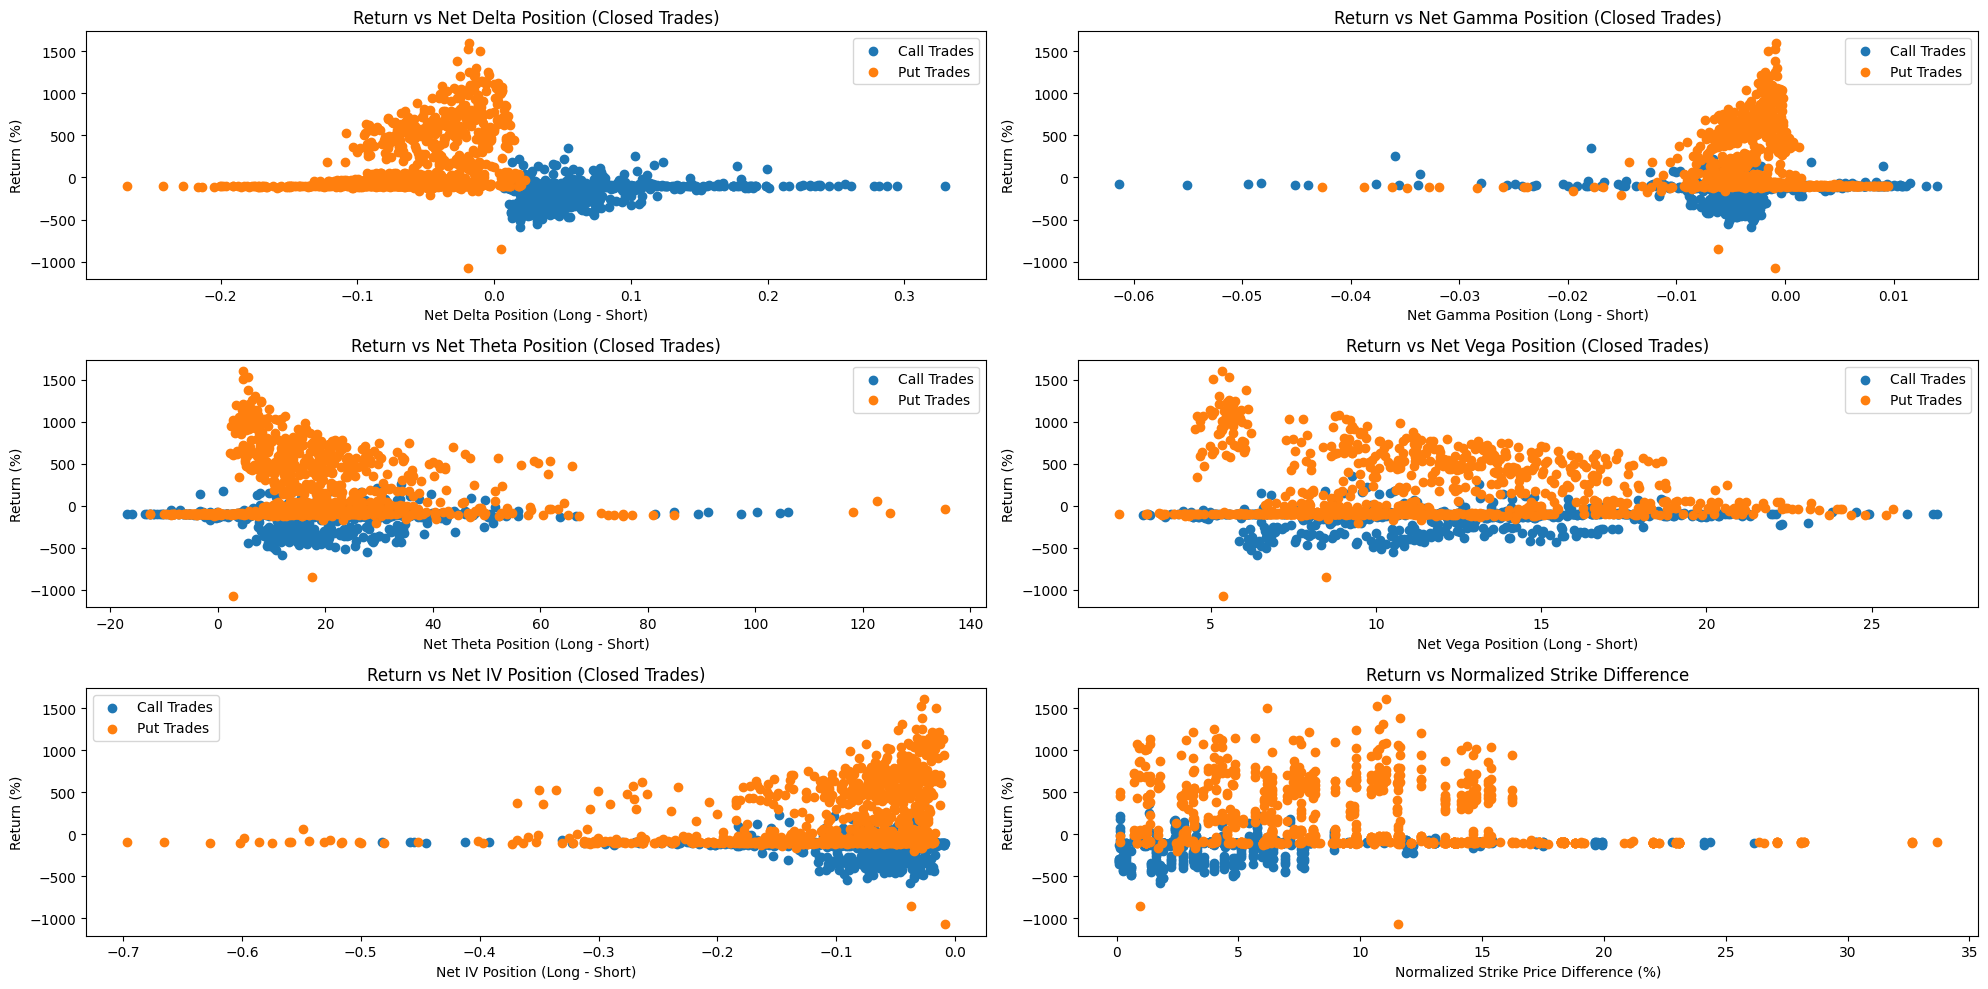

In [ ]:
symbol = 'QCOM'
timeframe = '1D'
historical_start_date = '2025-01-01'
historical_end_date = 'now'
initial_capital = 1000000  # Starting with $100,000
max_position_ratio_of_capital = 1  # Max 10% of cash per trade
max_number_of_open_positions = 2000  # Maximum number of open positions



######################
##### Stock Data #####
######################

# Get historical stock price data 
c, h, l, t = get_historical_stock_price(symbol = symbol,
                                            timeframe = timeframe,
                                            historical_start_date = historical_start_date,
                                            historical_end_date = historical_end_date, 
                                            headers = headers)

stock_data = pd.DataFrame([c, h, l, t]).T
stock_data.columns = ['Mid', 'High', 'Low', 'Date']
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

################################
##### Options Book Keeping #####
################################

# For each day's price, look at available options 
options_price_tracker = {}

# Keep track of symbols seen so far to make data pull easier
options_seen = set()

# In-memory cache: avoid repeatedly loading pickle if data is already present/fresh
options_cache_memory = {}  # dict[contract_symbol] -> DataFrame


# Keep track of open positions and their P&L
open_positions = {}  # {trade_id: {'entry_date', 'expiry_date', 'short_leg', 'long_leg', 'entry_credit', 'current_value'}}
closed_positions = []  # List of completed trades with P&L
trade_id_counter = 0

# Portfolio value tracking over time
portfolio_history = []
current_cash = initial_capital * max_position_ratio_of_capital
total_capital_deployed = 0
positions_history = []

#################################
##### Iterate Over Each Day #####
#################################

for high, low, mid, current_date in tqdm(list(zip(h, l, c, t))):
    
    #######################################
    ##### Get Historical Options Data #####
    #######################################

    # Filter options by strike price +/- 5% from current stock price 
    max_strike = high + (0.05 * high)
    min_strike = low - (0.05 * low)
    
    
    # Generate options symbols from strike price and expiry date
    put_option_symbols = generate_option_symbols(symbol = symbol,
                                                 current_date = current_date,
                                                 end_date_delta = (30, 120),
                                                 min_strike = min_strike,
                                                 max_strike = low,
                                                 strike_increment = 1, 
                                                 op_type = 'put')
    
    call_option_symbols = generate_option_symbols(symbol = symbol,
                                             current_date = current_date,
                                             end_date_delta = (30, 120),
                                             min_strike = high,
                                             max_strike = max_strike,
                                             strike_increment = 1, 
                                             op_type = 'call')
    
    

    # Get unseen options symbols since the previous iteration would have already pulled data 
    put_option_symbols = [s for s in put_option_symbols if s not in options_seen]
    call_option_symbols = [s for s in call_option_symbols if s not in options_seen]

    
    
    # Get historical data for options symbols generated (in-memory cache aware)
    put_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = put_option_symbols,
                                                        current_date = current_date,
                                                        stock_data  = stock_data,
                                                        timeframe = '1D', 
                                                        headers = headers)
    
    call_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = call_option_symbols,
                                                        current_date = current_date,
                                                        stock_data  = stock_data,
                                                        timeframe = '1D', 
                                                        headers = headers)
    
    # Keep track of all options symbols seen so far 
    options_seen = options_seen.union(set(put_option_symbols))
    options_seen = options_seen.union(set(call_option_symbols))
    
    # Merge dataframes for current time step
    for key in sorted(put_options_price_tracker.keys()):
        if key not in options_price_tracker:
            options_price_tracker[key] = put_options_price_tracker[key]
        else: 
            options_price_tracker[key] = pd.concat([options_price_tracker[key], put_options_price_tracker[key]])
        
    for key in sorted(call_options_price_tracker.keys()):
        if key not in options_price_tracker:
            options_price_tracker[key] = call_options_price_tracker[key]
        else: 
            options_price_tracker[key] = pd.concat([options_price_tracker[key], call_options_price_tracker[key]])
    
    concatenated_options = pd.concat(options_price_tracker.values())
    
    # Make sure we only look at out of money options 
    concatenated_options = concatenated_options[

                                ((concatenated_options['Type'] == 'call') &
                                (concatenated_options['Strike Price'] > concatenated_options['Current Stock Price'])) |
        
                                ((concatenated_options['Type'] == 'put') &
                                (concatenated_options['Strike Price'] < concatenated_options['Current Stock Price']))
                            ]
    
    current_options = concatenated_options[concatenated_options['Current Date'].dt.date == pd.to_datetime(current_date).date()]
    
    #######################################
    ##### Options Strategy Definition #####
    #######################################
    
    # Calendar Spread - Ensure Same Strike Price 
    strike_group = {int(key): group for key, group in current_options.groupby('Strike Price', sort = True)}

    # Identify Options Pairs Based on Forward Factor 
    list_of_options_dataframes = filter_option_trades_by_ff(strike_group = strike_group,
                                                            current_price = mid,
                                                            min_time_distance = 25,
                                                            max_time_distance = 120,
                                                            min_ff_perc = 10, 
                                                            max_ff_perc = 200,
                                                            current_date = current_date, 
                                                            print_output = False)
    
    # Sort by returned forward factors
    list_of_options_dataframes = sorted(list_of_options_dataframes, key = lambda x: x['Forward Factor'][0], reverse = True)
    
    # Calculate current portfolio value before opening new trades
    open_positions_value = get_all_open_positions_value(open_positions)
    current_portfolio_value = current_cash + open_positions_value
    
    ##############################################
    ##### Keep Track and Update Prior Trades #####
    ##############################################
    portfolio_history, open_positions, closed_positions, current_cash = check_existing_positions(portfolio_history,
                                                                            open_positions,
                                                                            closed_positions,
                                                                            current_date,
                                                                            current_cash,
                                                                            options_price_tracker,
                                                                            short_exit_limits = (-100, 200),
                                                                            long_exit_limits = (-100, 200),
                                                                            position_exit_limits = (-100, 200), 
                                                                            stock_data = stock_data)
    
    
    ##############################
    ##### Execute New Trades #####
    ##############################
    open_positions, num_trades_executed_today, current_cash, trade_id_counter = execute_identified_trades(list_of_options_dataframes = list_of_options_dataframes,
                                                                                        open_positions = open_positions,
                                                                                        current_date = current_date,
                                                                                        current_cash = current_cash,
                                                                                        trade_id_counter = trade_id_counter,
                                                                                        total_capital_deployed = total_capital_deployed,
                                                                                        max_number_of_open_positions = max_number_of_open_positions,
                                                                                        stock_strike_deviation_limit = 5,
                                                                                        max_position_ratio_of_capital_per_trade = 0.01)    
    
    
        
        
# After loop completes, create summary DataFrame
closed_trades_df = pd.DataFrame(closed_positions)
portfolio_df = pd.DataFrame(portfolio_history)

if len(closed_trades_df) > 0:
    closed_trades_df['return_pct'] = (closed_trades_df['final_pnl'] / 
                                       closed_trades_df['capital_deployed']) * 100
    
    print(f"Total Trades: {len(closed_trades_df)}")
    print(f"Total P&L: ${closed_trades_df['final_pnl'].sum():.2f}")
    print(f"Win Rate: {(closed_trades_df['final_pnl'] > 0).sum() / len(closed_trades_df) * 100:.2f}%")
    print(f"Average P&L: ${closed_trades_df['final_pnl'].mean():.2f}")

    # Reconciliation check: portfolio value vs closed P&L and open unrealized
    try:
        starting_trading_cash = initial_capital * max_position_ratio_of_capital
        idle_cash = initial_capital - starting_trading_cash

        final_value_with_idle = portfolio_df['total_value'].iloc[-1] + idle_cash
        initial_value_with_idle = portfolio_df['total_value'].iloc[0] + idle_cash

        realized_pnl = closed_trades_df['final_pnl'].sum() if len(closed_trades_df) else 0.0
        open_unrealized_pnl = portfolio_df['open_positions_value'].iloc[-1]

        expected_final_value = initial_capital + realized_pnl + open_unrealized_pnl

        print('--- Reconciliation ---')
        print(f"Final Value (+ idle):   ${final_value_with_idle:,.2f}")
        print(f"Expected Final Value:   ${expected_final_value:,.2f}")
        print(f"Difference:             ${final_value_with_idle - expected_final_value:,.2f}")
    except Exception as e:
        print('Reconciliation check skipped:', e)


# Plot factors vs returns
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].scatter(closed_trades_df['forward_factor'], closed_trades_df['return_pct'])
axs[0].set_xlabel('Forward Factor (%)')
axs[0].set_ylabel('Return (%)')
axs[0].set_title('Return vs Forward Factor for Closed Trades')

axs[1].hist(closed_trades_df['return_pct'], bins=100)
axs[1].set_xlabel('Return (%)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Distribution of Returns for Closed Trades')

axs[2].scatter(closed_trades_df['spread_distance'], closed_trades_df['return_pct'])
axs[2].set_xlabel('Spread Distance')
axs[2].set_ylabel('Return (%)')
axs[2].set_title('Return vs Spread Distance')
plt.show()

call_df = closed_trades_df[closed_trades_df['option_type'] == 'call']
put_df = closed_trades_df[closed_trades_df['option_type'] == 'put']

fig, axes = plt.subplots(3, 2, figsize=(20, 10))

# 1) Net Delta vs Return
axes[0][0].scatter(call_df['Delta_Long'] - call_df['Delta_Short'],
                 call_df['return_pct'], label='Call Trades')
axes[0][0].scatter(put_df['Delta_Long'] - put_df['Delta_Short'],
                 put_df['return_pct'], label='Put Trades')
axes[0][0].set_xlabel('Net Delta Position (Long - Short)')
axes[0][0].set_ylabel('Return (%)')
axes[0][0].set_title('Return vs Net Delta Position (Closed Trades)')
axes[0][0].legend()

# 2) Net Gamma vs Return
axes[0][1].scatter(call_df['Gamma Long'] - call_df['Gamma Short'],
                 call_df['return_pct'], label='Call Trades')
axes[0][1].scatter(put_df['Gamma Long'] - put_df['Gamma Short'],
                 put_df['return_pct'], label='Put Trades')
axes[0][1].set_xlabel('Net Gamma Position (Long - Short)')
axes[0][1].set_ylabel('Return (%)')
axes[0][1].set_title('Return vs Net Gamma Position (Closed Trades)')
axes[0][1].legend()

# 3) Net Theta vs Return
axes[1][0].scatter(call_df['Theta Long'] - call_df['Theta Short'],
                 call_df['return_pct'], label='Call Trades')
axes[1][0].scatter(put_df['Theta Long'] - put_df['Theta Short'],
                 put_df['return_pct'], label='Put Trades')
axes[1][0].set_xlabel('Net Theta Position (Long - Short)')
axes[1][0].set_ylabel('Return (%)')
axes[1][0].set_title('Return vs Net Theta Position (Closed Trades)')
axes[1][0].legend()

# 4) Net Vega vs Return
axes[1][1].scatter(call_df['Vega Long'] - call_df['Vega Short'],
                 call_df['return_pct'], label='Call Trades')
axes[1][1].scatter(put_df['Vega Long'] - put_df['Vega Short'],
                 put_df['return_pct'], label='Put Trades')
axes[1][1].set_xlabel('Net Vega Position (Long - Short)')
axes[1][1].set_ylabel('Return (%)')
axes[1][1].set_title('Return vs Net Vega Position (Closed Trades)')
axes[1][1].legend()

# 5) Net IV vs Return
axes[2][0].scatter(call_df['IV Long'] - call_df['IV Short'],
                 call_df['return_pct'], label='Call Trades')
axes[2][0].scatter(put_df['IV Long'] - put_df['IV Short'],
                 put_df['return_pct'], label='Put Trades')
axes[2][0].set_xlabel('Net IV Position (Long - Short)')
axes[2][0].set_ylabel('Return (%)')
axes[2][0].set_title('Return vs Net IV Position (Closed Trades)')
axes[2][0].legend()


# 6) Normalized Strike Difference vs Return (in %)
x_call = 100 * np.abs(call_df['entry_stock_price'] - call_df['strike']) / call_df['strike']
x_put = 100 * np.abs(put_df['entry_stock_price'] - put_df['strike']) / put_df['strike']
axes[2][1].scatter(x_call, call_df['return_pct'], label='Call Trades')
axes[2][1].scatter(x_put, put_df['return_pct'], label='Put Trades')
axes[2][1].set_xlabel('Normalized Strike Price Difference (%)')
axes[2][1].set_ylabel('Return (%)')
axes[2][1].set_title('Return vs Normalized Strike Difference')
axes[2][1].legend()
plt.tight_layout()
plt.show()


BACKTEST PERFORMANCE SUMMARY (Full Capital)
Initial Capital:        $1,000,000.00
Final Portfolio Value:  $220,090.00
Total Return:           -77.99%
Annualized Return:      -83.39%
Sharpe Ratio:           1.41
Maximum Drawdown:       -98.80%

Trading Period:         2025-01-01 to 2025-11-05
Days Elapsed:           308

Total Trades:           886
Win Rate:               24.38%
Average Win:            $6425.11
Average Loss:           $-3150.34
Profit Factor:          0.66


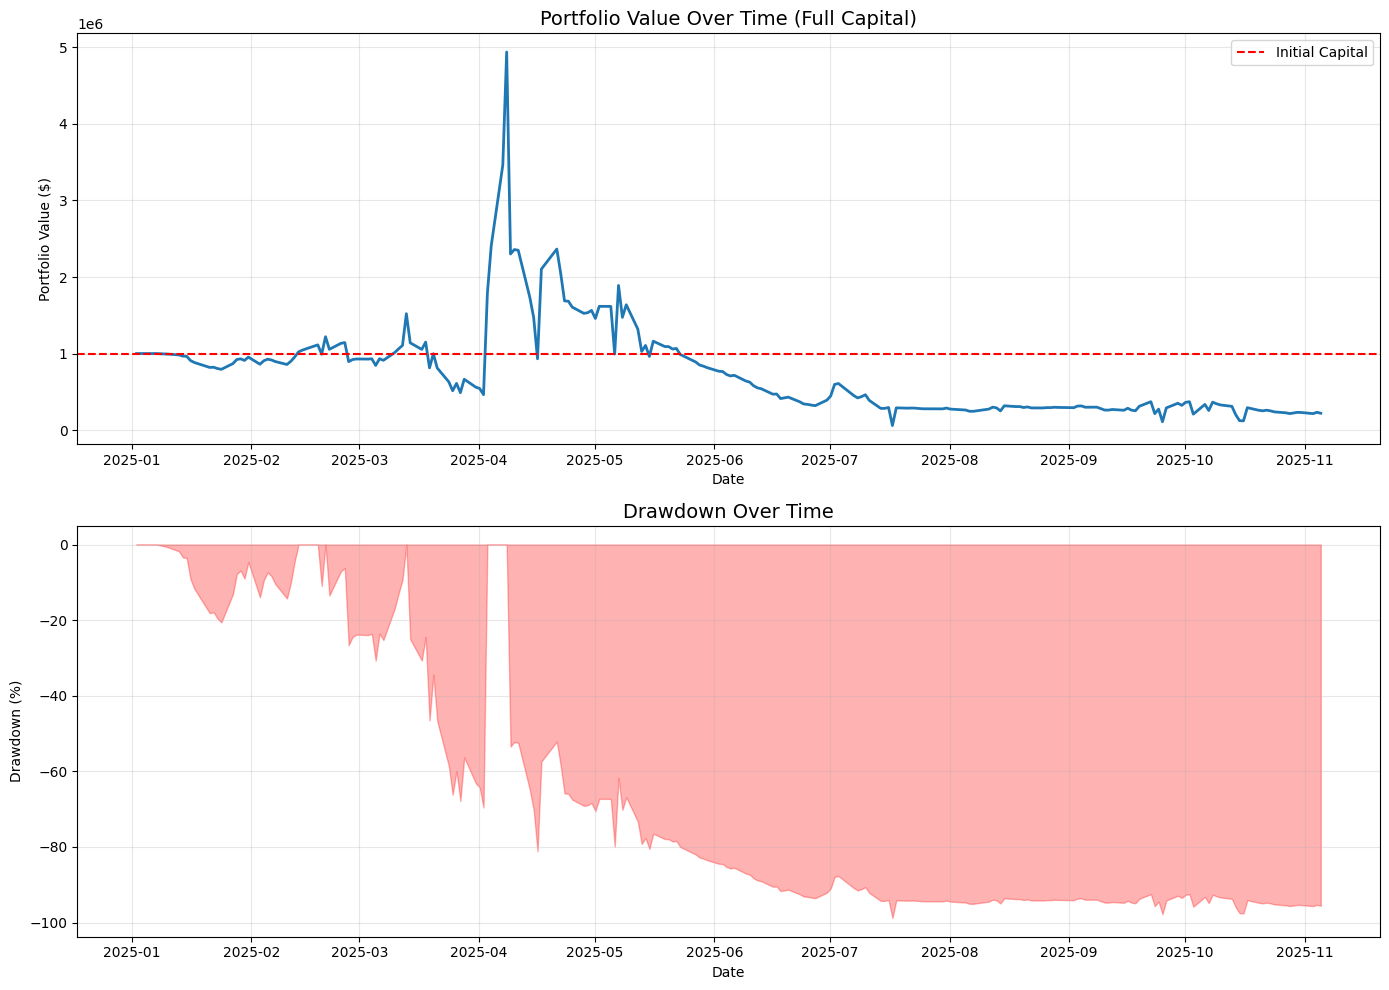

In [24]:
# Convert to DataFrame for analysis
portfolio_df = pd.DataFrame(portfolio_history)
closed_trades_df = pd.DataFrame(closed_positions)

# Baseline: only a fraction of capital was actively traded; add idle cash back to equity
starting_trading_cash = initial_capital * max_position_ratio_of_capital  # cash allocated to trades
idle_cash = initial_capital - starting_trading_cash                      # idle cash held constant

# Build a full-equity series including idle cash
portfolio_df['equity_full'] = portfolio_df['total_value'] + idle_cash

# Calculate performance metrics on full equity
final_portfolio_value = portfolio_df['equity_full'].iloc[-1]
total_return = ((final_portfolio_value - initial_capital) / initial_capital) * 100

# Calculate time period
start_date = pd.to_datetime(historical_start_date, utc=True)
end_date = pd.to_datetime(portfolio_df['date'].iloc[-1], utc=True)
days_elapsed = (end_date - start_date).days
years_elapsed = days_elapsed / 365.25 if days_elapsed > 0 else np.nan

# Annualized return (guard for very short periods)
if years_elapsed and not np.isnan(years_elapsed) and years_elapsed > 0:
    annualized_return = ((final_portfolio_value / initial_capital) ** (1 / years_elapsed) - 1) * 100
else:
    annualized_return = np.nan

# Calculate daily returns on full equity
portfolio_df['daily_return'] = portfolio_df['equity_full'].pct_change()

# Sharpe Ratio (assuming risk-free rate of 4%)
risk_free_rate = 0.04
risk_free_daily = risk_free_rate / 252
excess_returns = portfolio_df['daily_return'] - risk_free_daily
excess_std = excess_returns.std()
sharpe_ratio = (excess_returns.mean() / excess_std) * np.sqrt(252) if excess_std and not np.isnan(excess_std) else np.nan

# Maximum drawdown on full equity
portfolio_df['cumulative_max'] = portfolio_df['equity_full'].cummax()
portfolio_df['drawdown'] = (portfolio_df['equity_full'] - portfolio_df['cumulative_max']) / portfolio_df['cumulative_max']
max_drawdown = portfolio_df['drawdown'].min() * 100

# Win rate and profit factor
if len(closed_trades_df) > 0:
    win_rate = (closed_trades_df['final_pnl'] > 0).sum() / len(closed_trades_df) * 100
    avg_win = closed_trades_df[closed_trades_df['final_pnl'] > 0]['final_pnl'].mean()
    avg_loss = closed_trades_df[closed_trades_df['final_pnl'] < 0]['final_pnl'].mean()
    total_wins = closed_trades_df[closed_trades_df['final_pnl'] > 0]['final_pnl'].sum()
    total_losses = closed_trades_df[closed_trades_df['final_pnl'] < 0]['final_pnl'].sum()
    profit_factor = (total_wins / abs(total_losses)) if total_losses != 0 else np.inf
else:
    win_rate = avg_win = avg_loss = 0
    profit_factor = np.nan

# Print Performance Summary
print("=" * 60)
print("BACKTEST PERFORMANCE SUMMARY (Full Capital)")
print("=" * 60)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Portfolio Value:  ${final_portfolio_value:,.2f}")
print(f"Total Return:           {total_return:.2f}%")
print(f"Annualized Return:      {annualized_return:.2f}%" if not np.isnan(annualized_return) else "Annualized Return:      n/a")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}" if not np.isnan(sharpe_ratio) else "Sharpe Ratio:           n/a")
print(f"Maximum Drawdown:       {max_drawdown:.2f}%")
print(f"\nTrading Period:         {start_date.date()} to {end_date.date()}")
print(f"Days Elapsed:           {days_elapsed}")
print(f"\nTotal Trades:           {len(closed_trades_df)}")
print(f"Win Rate:               {win_rate:.2f}%")
print(f"Average Win:            ${0 if np.isnan(avg_win) else avg_win:.2f}")
print(f"Average Loss:           ${0 if np.isnan(avg_loss) else avg_loss:.2f}")
print(f"Profit Factor:          {profit_factor:.2f}" if not np.isnan(profit_factor) and not np.isinf(profit_factor) else f"Profit Factor:          {profit_factor}")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Portfolio value (full equity)
axes[0].plot(portfolio_df['date'], portfolio_df['equity_full'], linewidth=2)
axes[0].axhline(y=initial_capital, color='r', linestyle='--', label='Initial Capital')
axes[0].set_title('Portfolio Value Over Time (Full Capital)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
axes[1].fill_between(portfolio_df['date'], portfolio_df['drawdown'] * 100, 0, alpha=0.3, color='red')
axes[1].set_title('Drawdown Over Time', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Other: Power Law Distribution Controls  

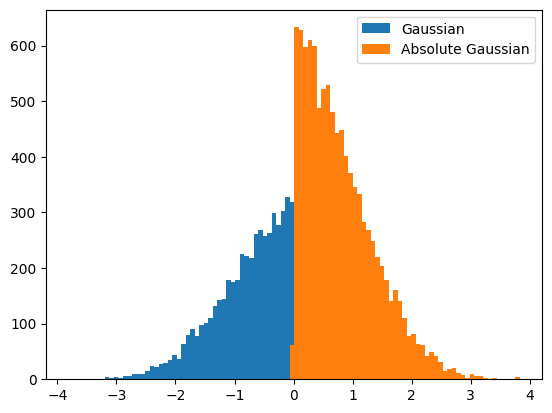

In [203]:
y = np.random.randn(10000)
abs_y = np.abs(y)
bins = plt.hist(y, bins = 100, label = 'Gaussian')
bins_abs = plt.hist(abs_y, bins = bins[1], label = 'Absolute Gaussian')
plt.legend()
plt.show()

/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:2: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 1, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:4: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 2, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:6: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 3, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:8: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 5, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:10: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 10, 0))

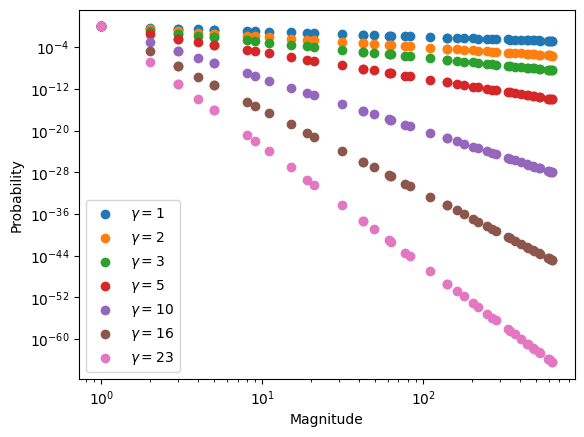

In [212]:
plt.figure()
for k in [1, 2, 3, 5, 10, 16, 23]:
    plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), k, 0)),
                x = bins_abs[0][46:], label = f'$\gamma = {k}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Probability')
plt.legend()
plt.show()